In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import bayesian_stats_course_tools

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Urn example

In [45]:
def binomial(n,p):
    return scipy.stats.Binomial(n=n,p=p)

def urn_prior(n,r):
    return 1/(n+1)*np.ones_like(r)

def urn_likelyhood(r,n,t,k):
    theta=r/n
    return scipy.special.binom(t,k)*theta**k *(1-theta)**(t-k)

def urn_posterior(r,n,t,k):
    return urn_likelyhood(r,n,t,k)*urn_prior(n,r)

def normalize(arr):
    return arr/np.sum(arr)

def simulate_urn(n,t,k):
    r=np.arange(1,n+1)
    post=urn_posterior(r,n,t,k)
    post=normalize(post)
    # plt.plot(r,post, label=f"posterior, k={k},t={t}.4f,n={n}")
    # plt.xlabel("r")
    # plt.ylabel("$P$")
    # plt.legend()
    return r,post



In [39]:
# a=binomial(10,0.34)
urn_likelyhood(2,10,5,2)

np.float64(0.2048000000000001)

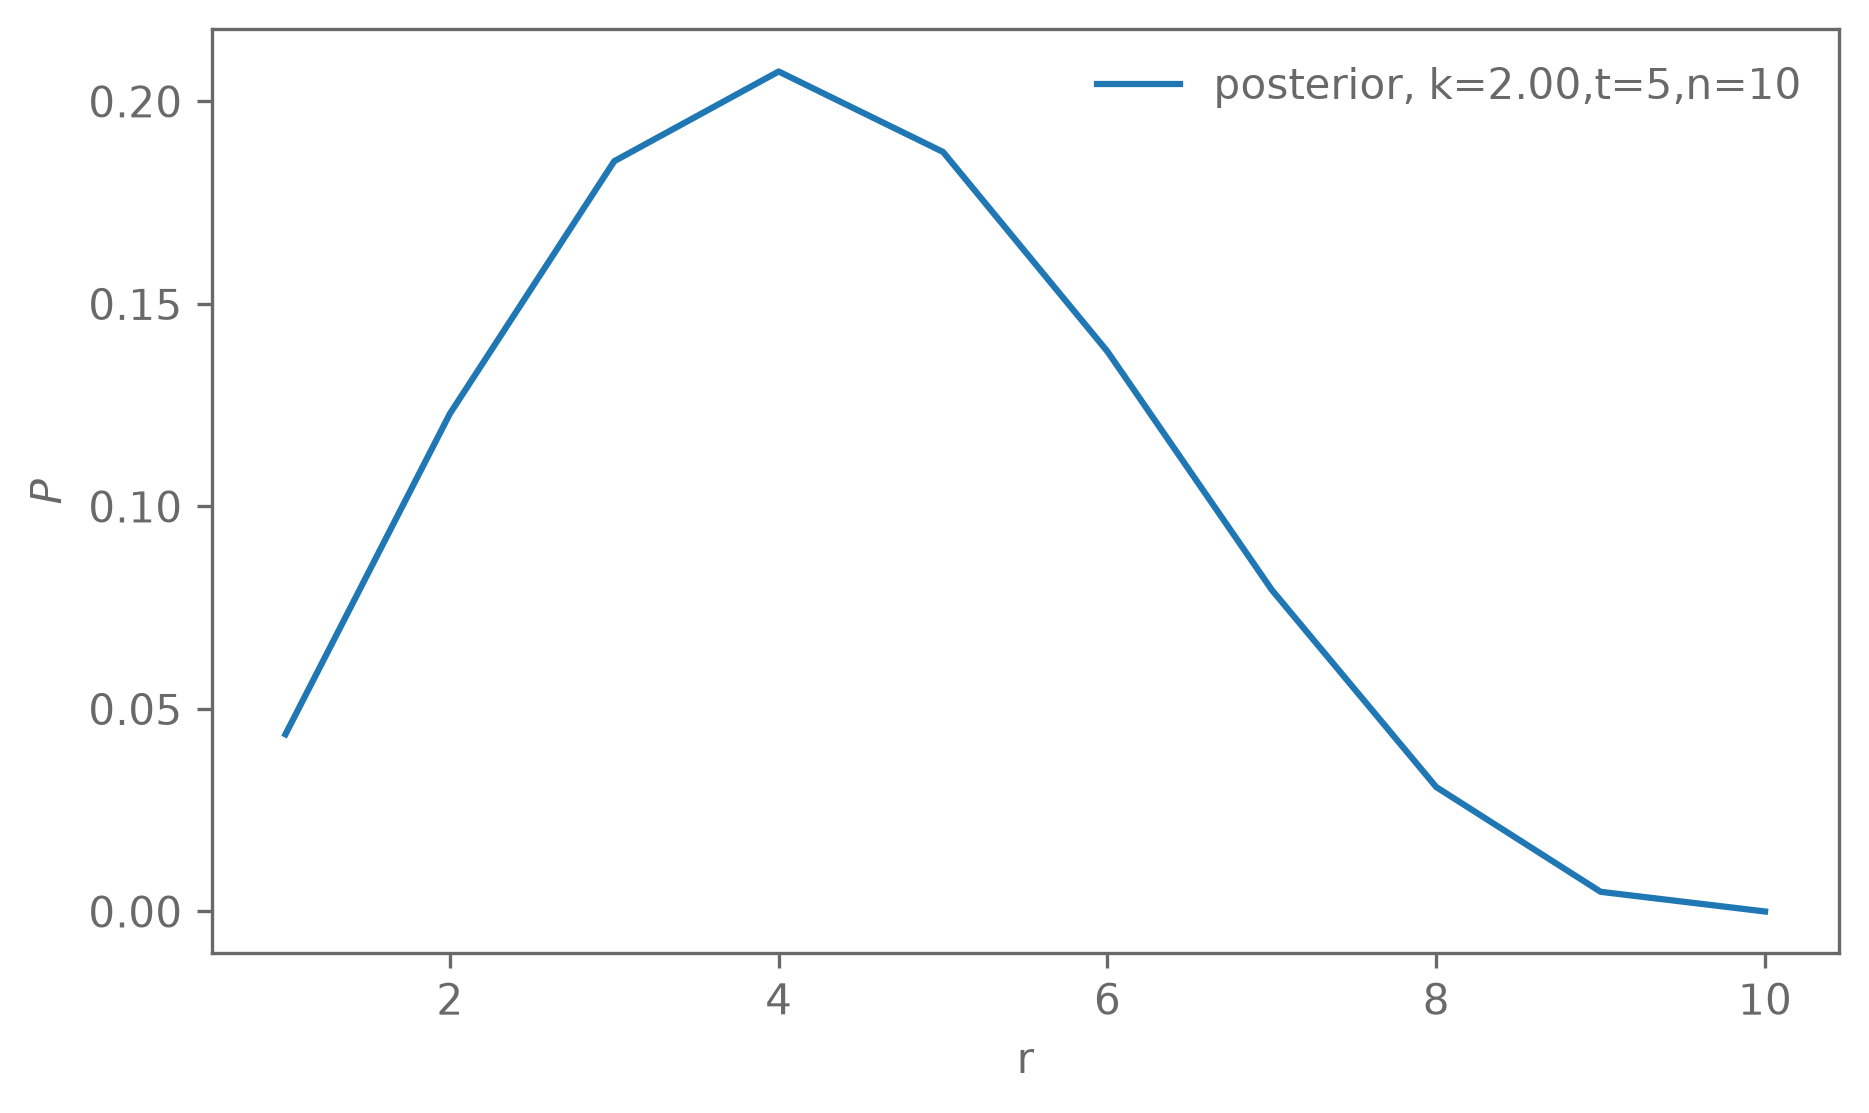

In [44]:
n=10
t=5
k=2
r=np.arange(1,n+1)
post=urn_posterior(r,n,t,k)
post=normalize(post)
plt.plot(r,post, label=f"posterior, k={k:.2f},t=5,n=10")
plt.xlabel("r")
plt.ylabel("$P$")
plt.legend()

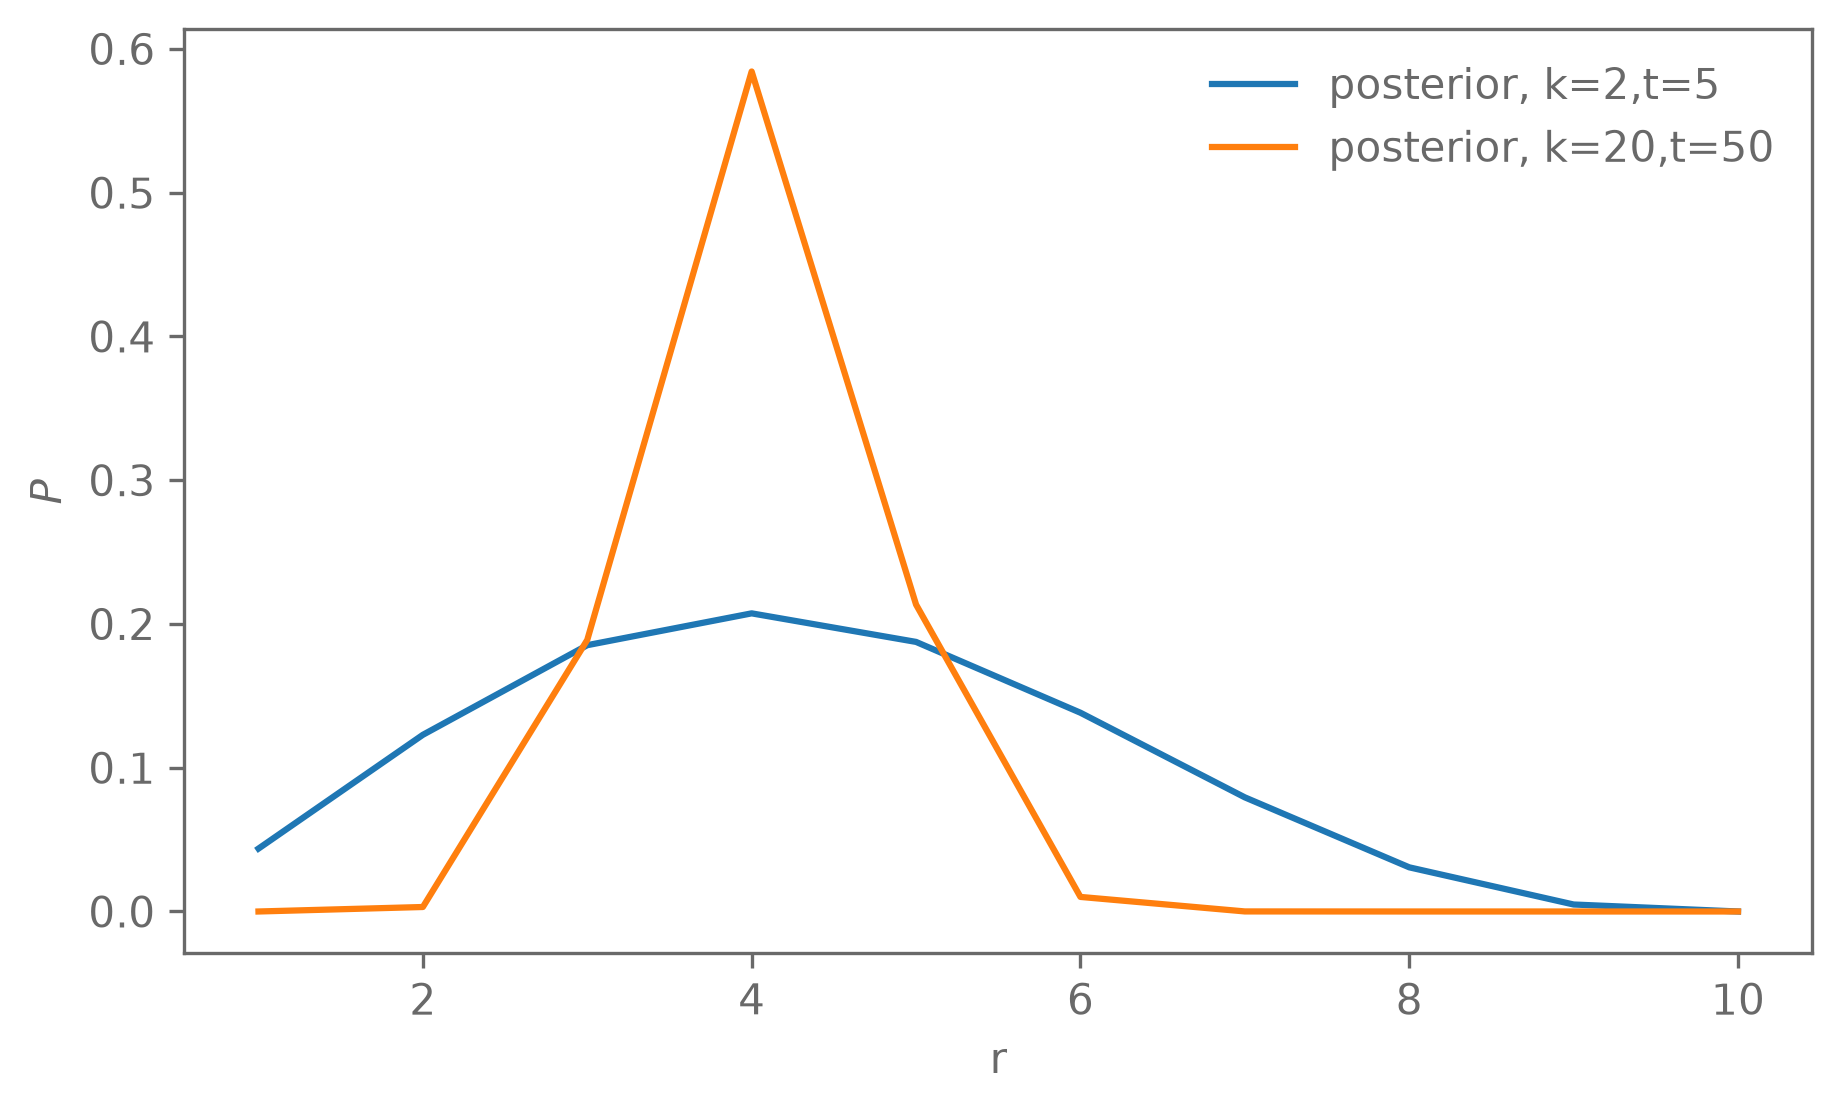

In [47]:
r1,post1=simulate_urn(n=10,t=50,k=20)
r2,post2=simulate_urn(10,5,2)

plt.plot(r1,post2, label="posterior, k=2,t=5")
plt.plot(r1,post1, label="posterior, k=20,t=50")
plt.xlabel("r")
plt.ylabel("$P$")
plt.legend()

## Update the prior

In [49]:
def update_prior(r,n,t,k):
    return urn_posterior(r,n,t,k)
def update_posterior(r,n,t,k):
    return urn_likelyhood(r,n,t,k,)*update_prior(r,n,t,k)

In [ ]:
r1,post1=simulate_urn(n=10,t=5,k=2)
r2,post2=simulate_urn(n=10,t=50,k=20)
post3=normalize(update_posterior(r1,n=10,t=5,k=2))
post4=normalize(update_posterior(r1,n=10,t=50,k=20))

Text(0, 0.5, '$P$')

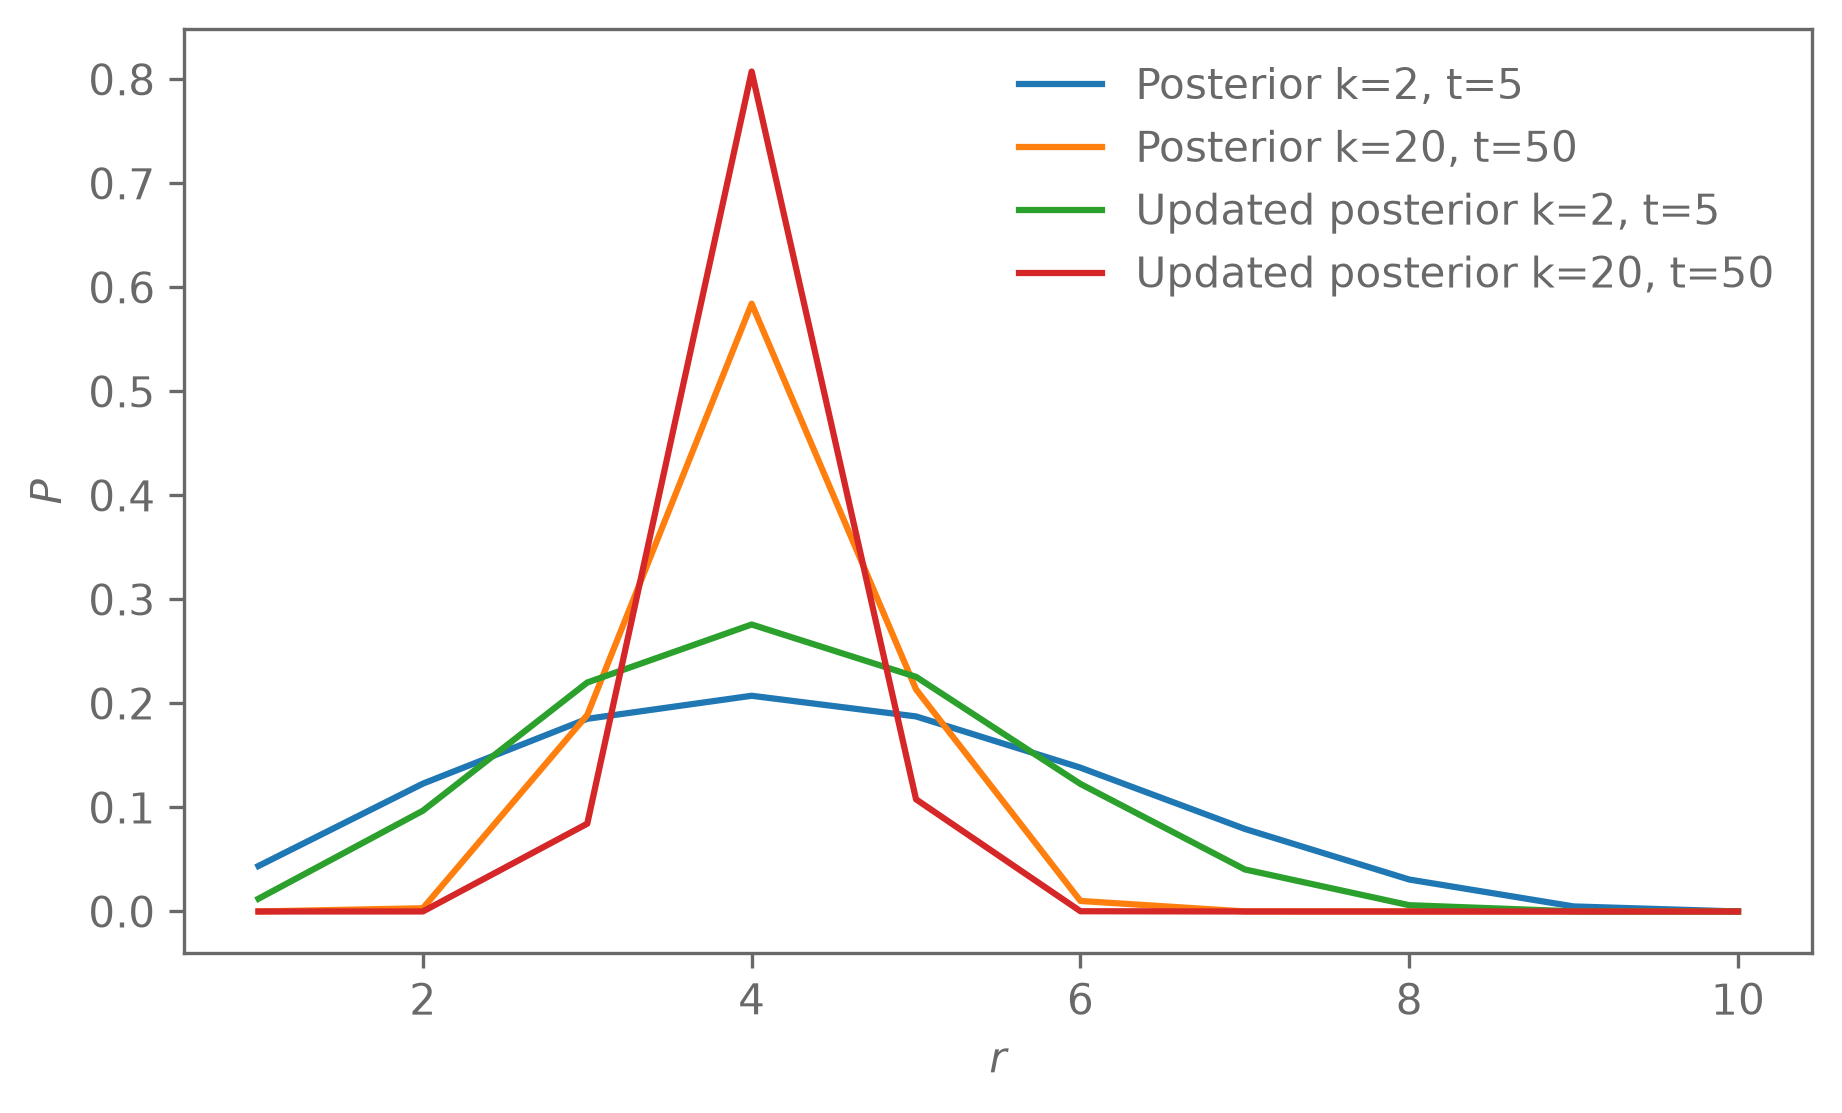

In [51]:
plt.plot(r1,post1,label="Posterior k=2, t=5")
plt.plot(r1,post2,label="Posterior k=20, t=50")
plt.plot(r1,post3,label="Updated posterior k=2, t=5")
plt.plot(r1,post4,label="Updated posterior k=20, t=50")
plt.legend()
plt.xlabel("$r$")
plt.ylabel("$P$")

# Model comparison

In [78]:
# generate model data as currently non is available
def generate_model_data_linear():
    a,b,n=2,3,20
    f = lambda x: a*x+b
    x=np.random.random(size=n)*20
    yerr= np.random.normal(0,1,size=n)*5
    sigma_y=np.mean(np.absolute(yerr))
    y= f(x) + yerr
    return x,y, sigma_y

<ErrorbarContainer object of 3 artists>

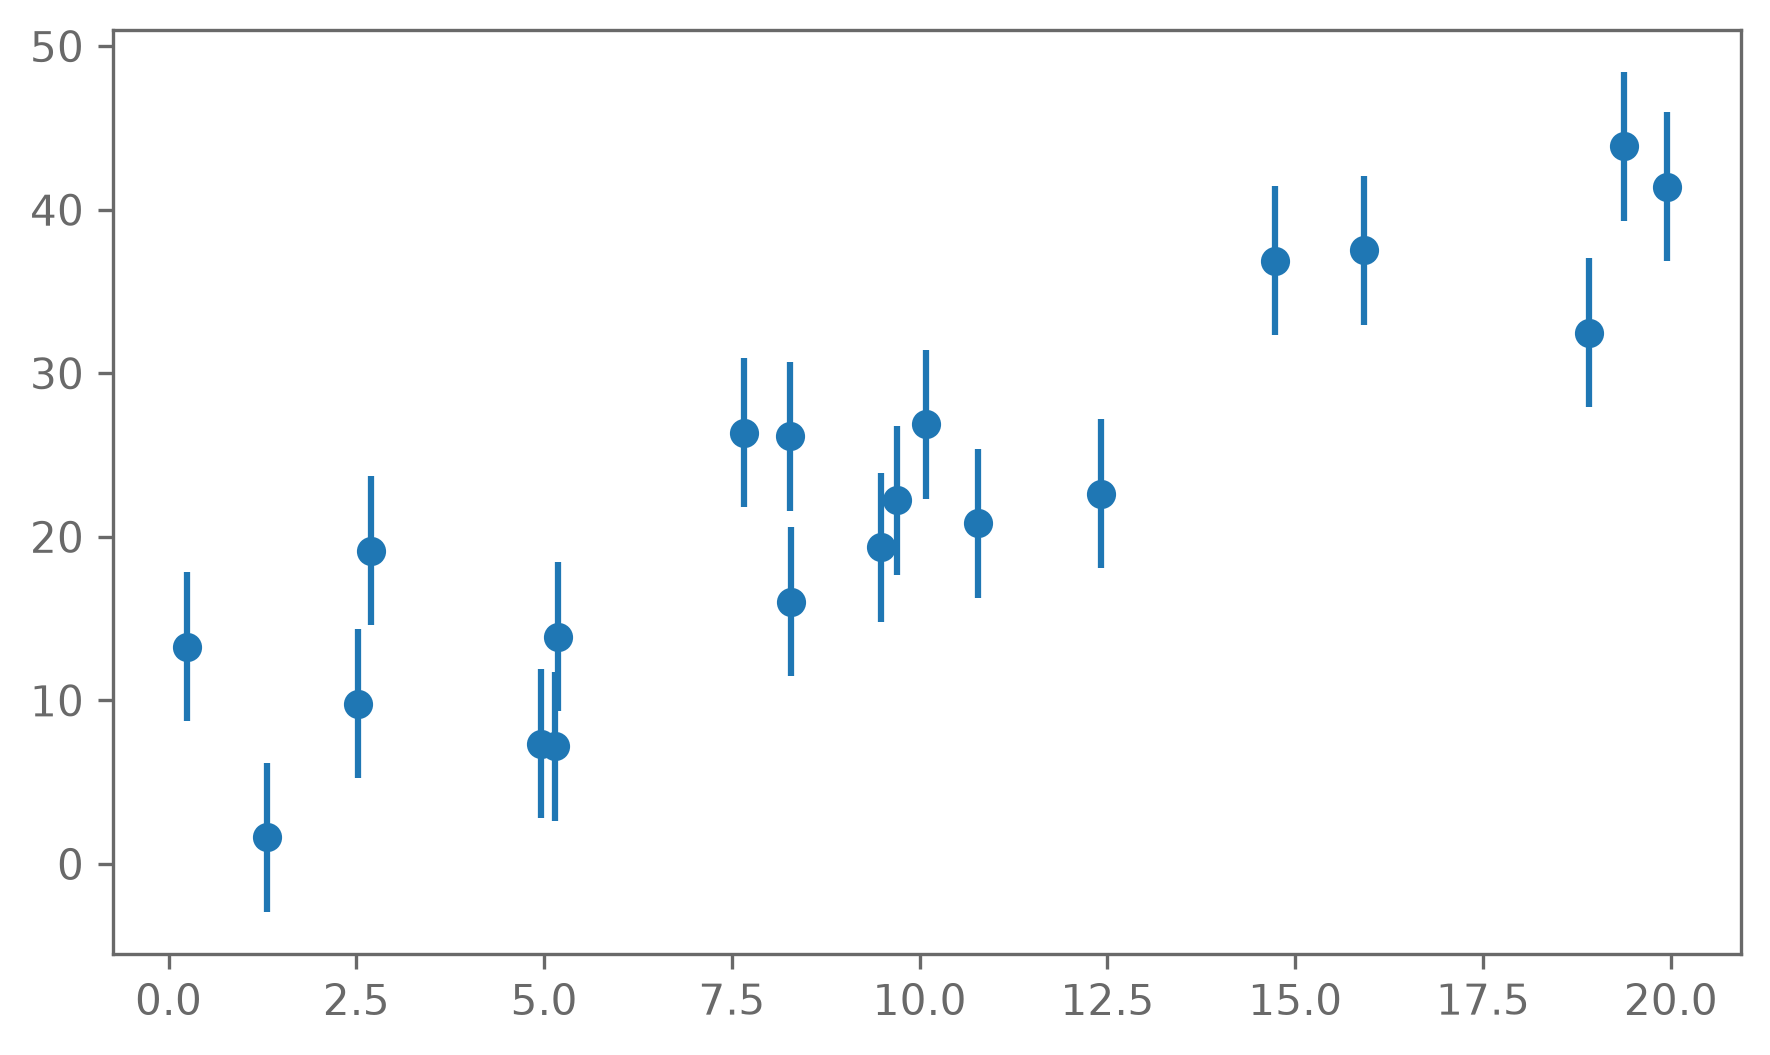

In [79]:
x,y,yerr=generate_model_data_linear()
plt.errorbar(x,y,yerr=np.ones_like(x)*yerr, fmt="o")

In [111]:
def model(m,b,x):
    return m*x+b

def log_likelihood_probability(y,m,b,x,yerr):
    prediction=model(m,b,x)
    n=len(y)
    return (-0.5* np.sum((y-prediction)**2 / yerr**2) -n/2*np.log(2*np.pi*yerr**2))

In [85]:
priorm=scipy.stats.norm(loc=1,scale=1)
priorb=scipy.stats.norm(loc=0,scale=1.2)

def log_prior_probability(m,b):
    return priorm.logpdf(m) + priorb.logpdf(b)

In [92]:
def sample_prior(n_sample):
    """Sample n_sample times from the prior distribution."""
    return np.vstack((priorm.rvs(n_sample), priorb.rvs(n_sample))).T
np.random.seed(42)
prior_model_predictive = np.array(
[model(*parameters, x) for parameters in sample_prior(n_sample=20)]
)

In [86]:
log_prior_probability(1,1)

np.float64(-2.3674208454255226)

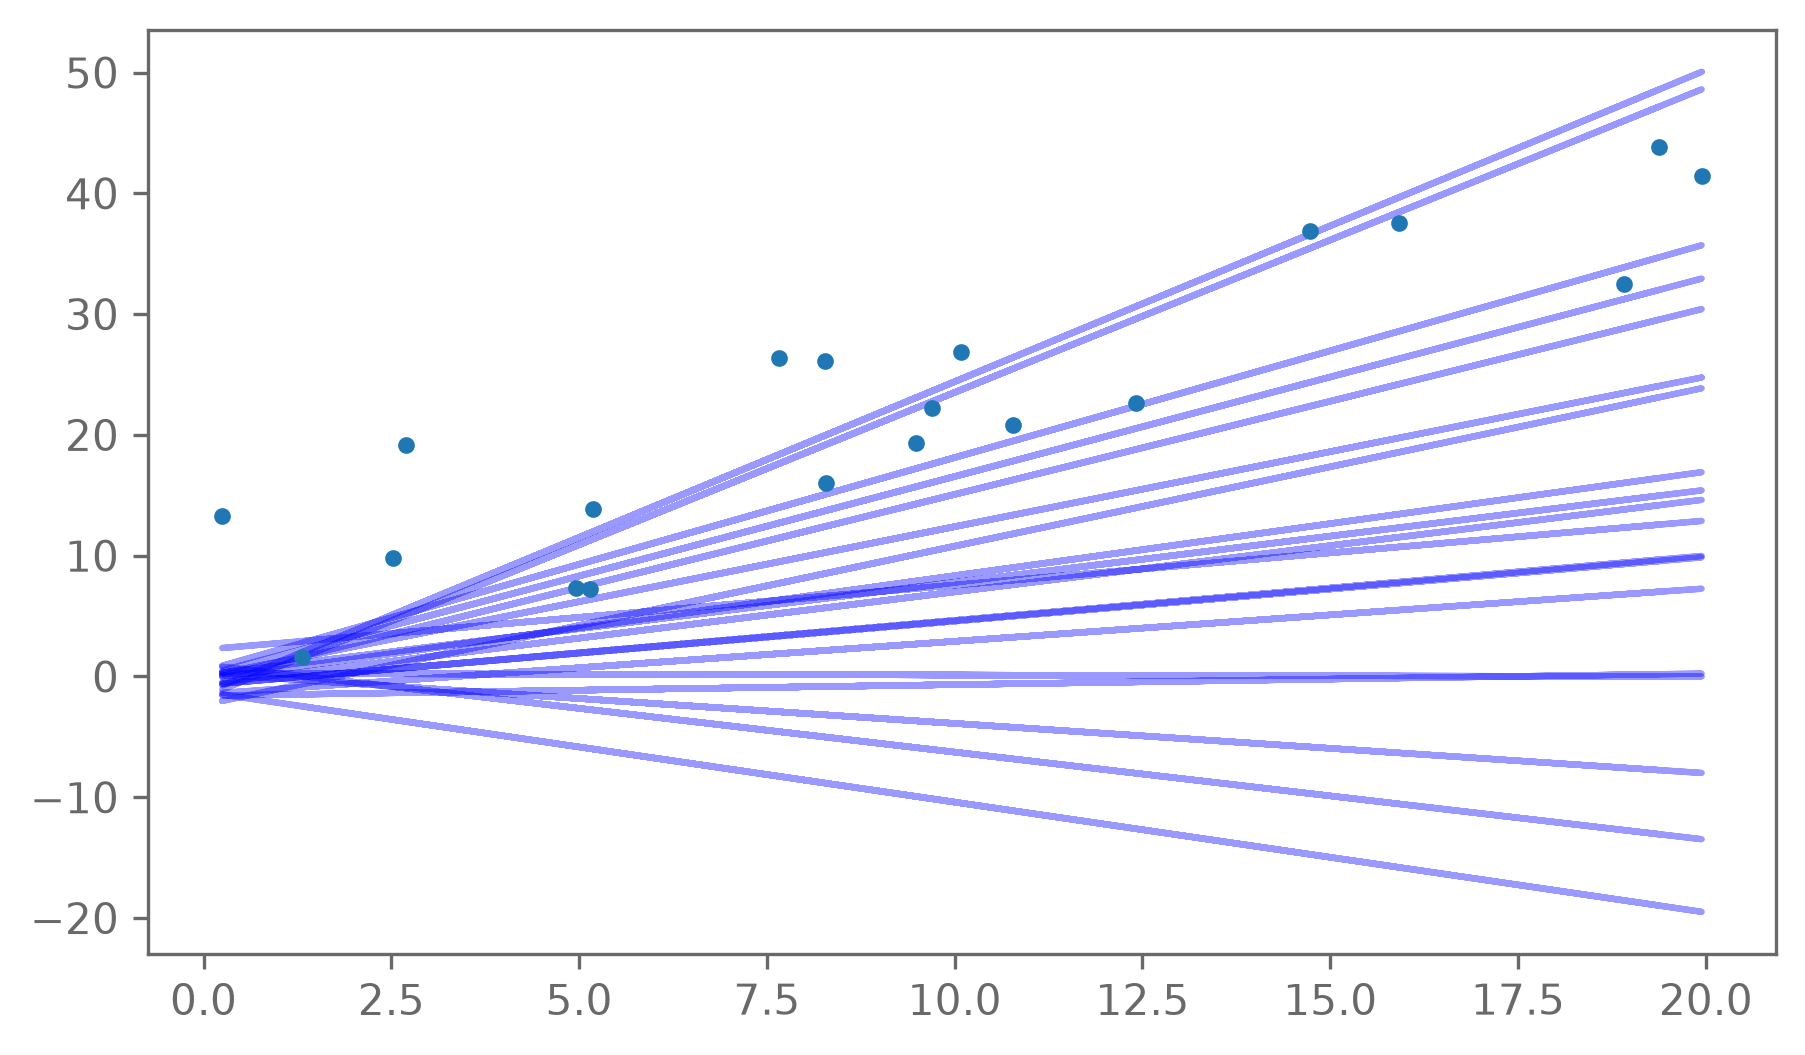

In [105]:
for n in range(1,len(prior_model_predictive)):
    plt.plot(x,prior_model_predictive[n], color="b",alpha=0.4)
plt.plot(x,y, ".")

### fitting model

In [108]:
def log_posterior_probability(m, b, x, sigma_y, y):
    return (
    log_likelihood_probability(y, m, b, x, sigma_y)
    + log_prior_probability(m, b)
    )
def negative_log_posterior(theta, x, sigma_y, y):
    m, b = theta
    return -log_posterior_probability(m, b, x, sigma_y, y)

In [116]:
MAP_result = scipy.optimize.minimize(
fun=negative_log_posterior,
x0=(1, 0),
args=(x, yerr, y)
)
m_MAP, b_MAP = MAP_result.x
m_true = 2
b_true = 3
print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")
print(f"m_true = {m_true:.3f}, b_true = {b_true:.3f}")

MAP results
m_MAP = 2.063, b_MAP = 1.682
m_true = 2.000, b_true = 3.000


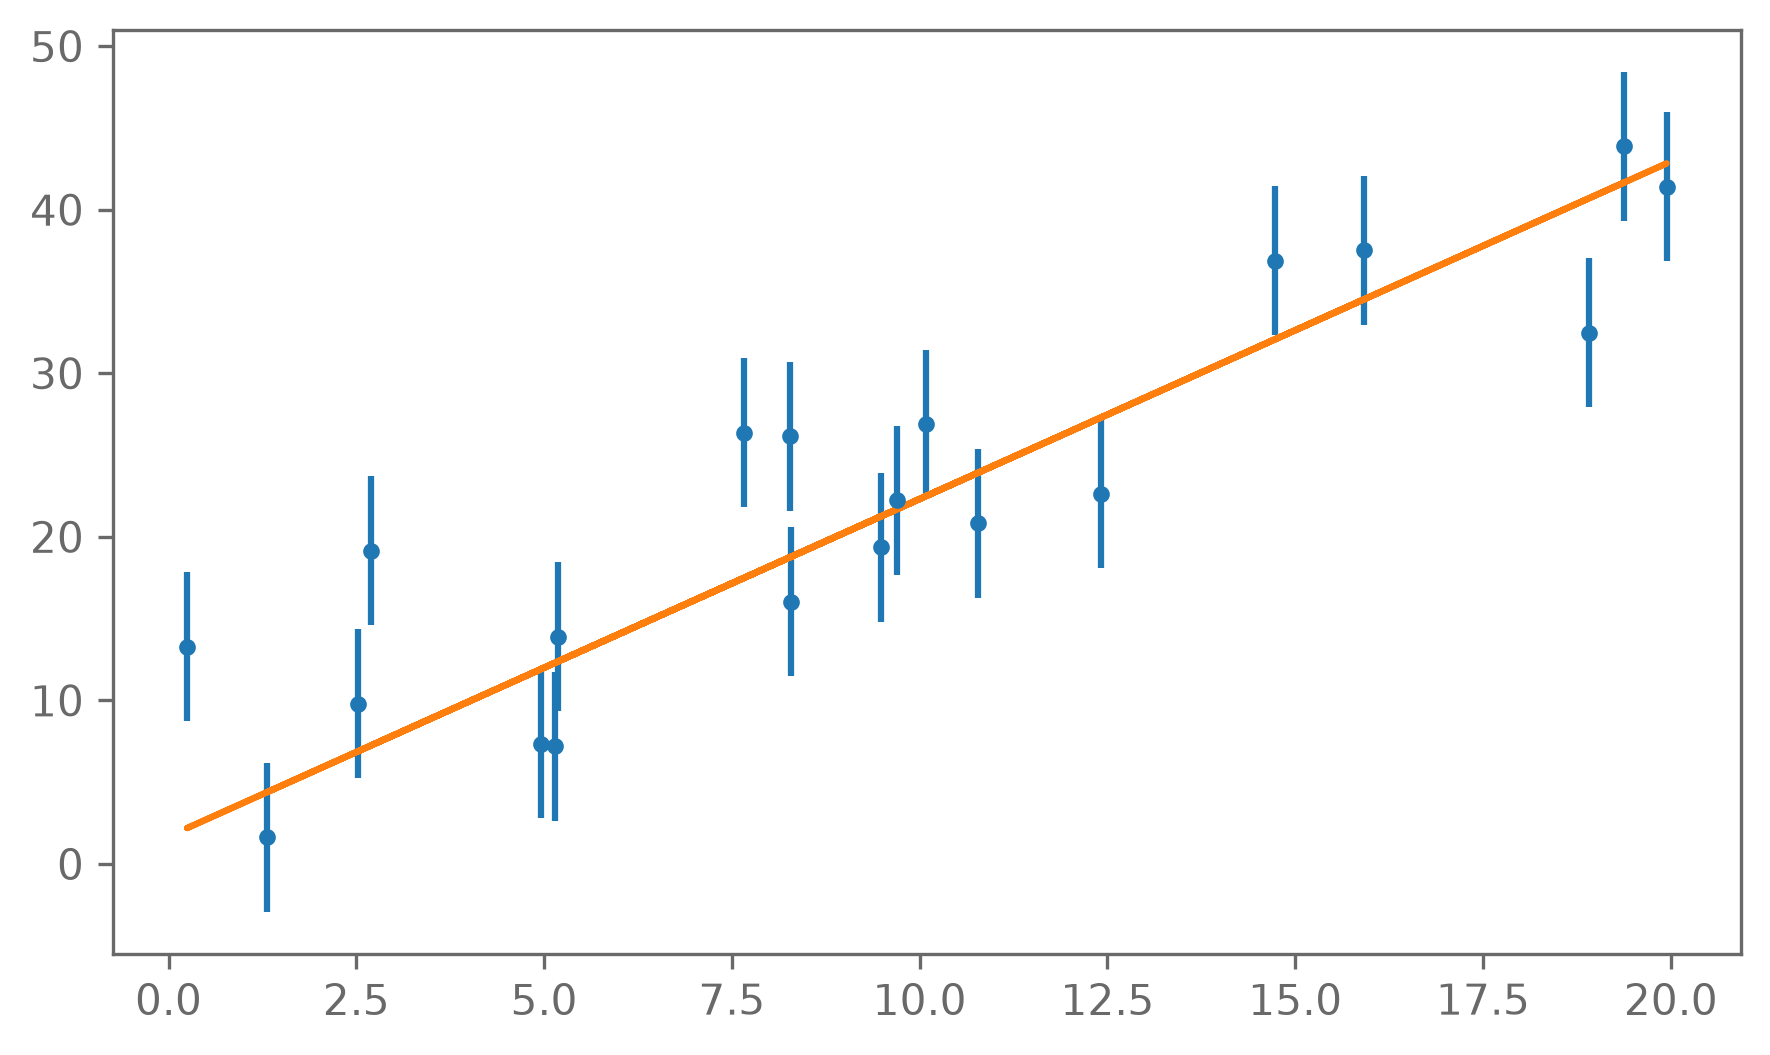

In [115]:
plt.errorbar(x,y,yerr=yerr, fmt=".", label="data")
plt.plot(x,model(m_MAP,b_MAP, x), label="model MAP")

### Posterior sampling

In [19]:
import emcee

In [ ]:
def log_posterior_wrapper(theta, x, sigma_y, y):
    m, b = theta
    return log_posterior_probability(m, b, x, sigma_y, y)

# emcee requires some extra settings to run
n_param = 2       # Number of parameter we are sampling
n_walker = 10     # Number of walkers. This just needs to be
                  # larger than 2*n_param + 1!  is the nr of mcmc-chains run simulatneously
n_step = 5000     # How many steps each walker will take. The number
                  # of samples will be n_walker*n_step

# The starting point for each walker
theta_init = np.array([0.5, 0.5]) \
    + 0.1*np.random.normal(size=(n_walker, n_param))
sampler = emcee.EnsembleSampler(
    nwalkers=n_walker, ndim=n_param,
    log_prob_fn=log_posterior_wrapper,
    args=(x, yerr, y)
)
state = sampler.run_mcmc(theta_init, nsteps=n_step)

In [124]:
# The samples will be correlated, this checks how correlated they are
# We will discuss this once we come to MCMC methods
print("Auto-correlation time:")
for name, value in zip(["m", "b", "f"], sampler.get_autocorr_time()):
    print(f"{name} = {value:.1f}")
# We need to discard the beginning of the chain (a few auto-correlation times)
# to get rid of the initial conditions
chain = sampler.get_chain(discard=300, thin=10, flat=True)

Auto-correlation time:
m = 44.4
b = 35.6


In [125]:
print("Posterior results (mean±std)")
print(f"m = {np.mean(chain[:,0]):.2f}±{np.std(chain[:,0]):.2f}")
print(f"b = {np.mean(chain[:,1]):.2f}±{np.std(chain[:,1]):.2f}")


Posterior results (mean±std)
m = 2.06±0.12
b = 1.69±1.01


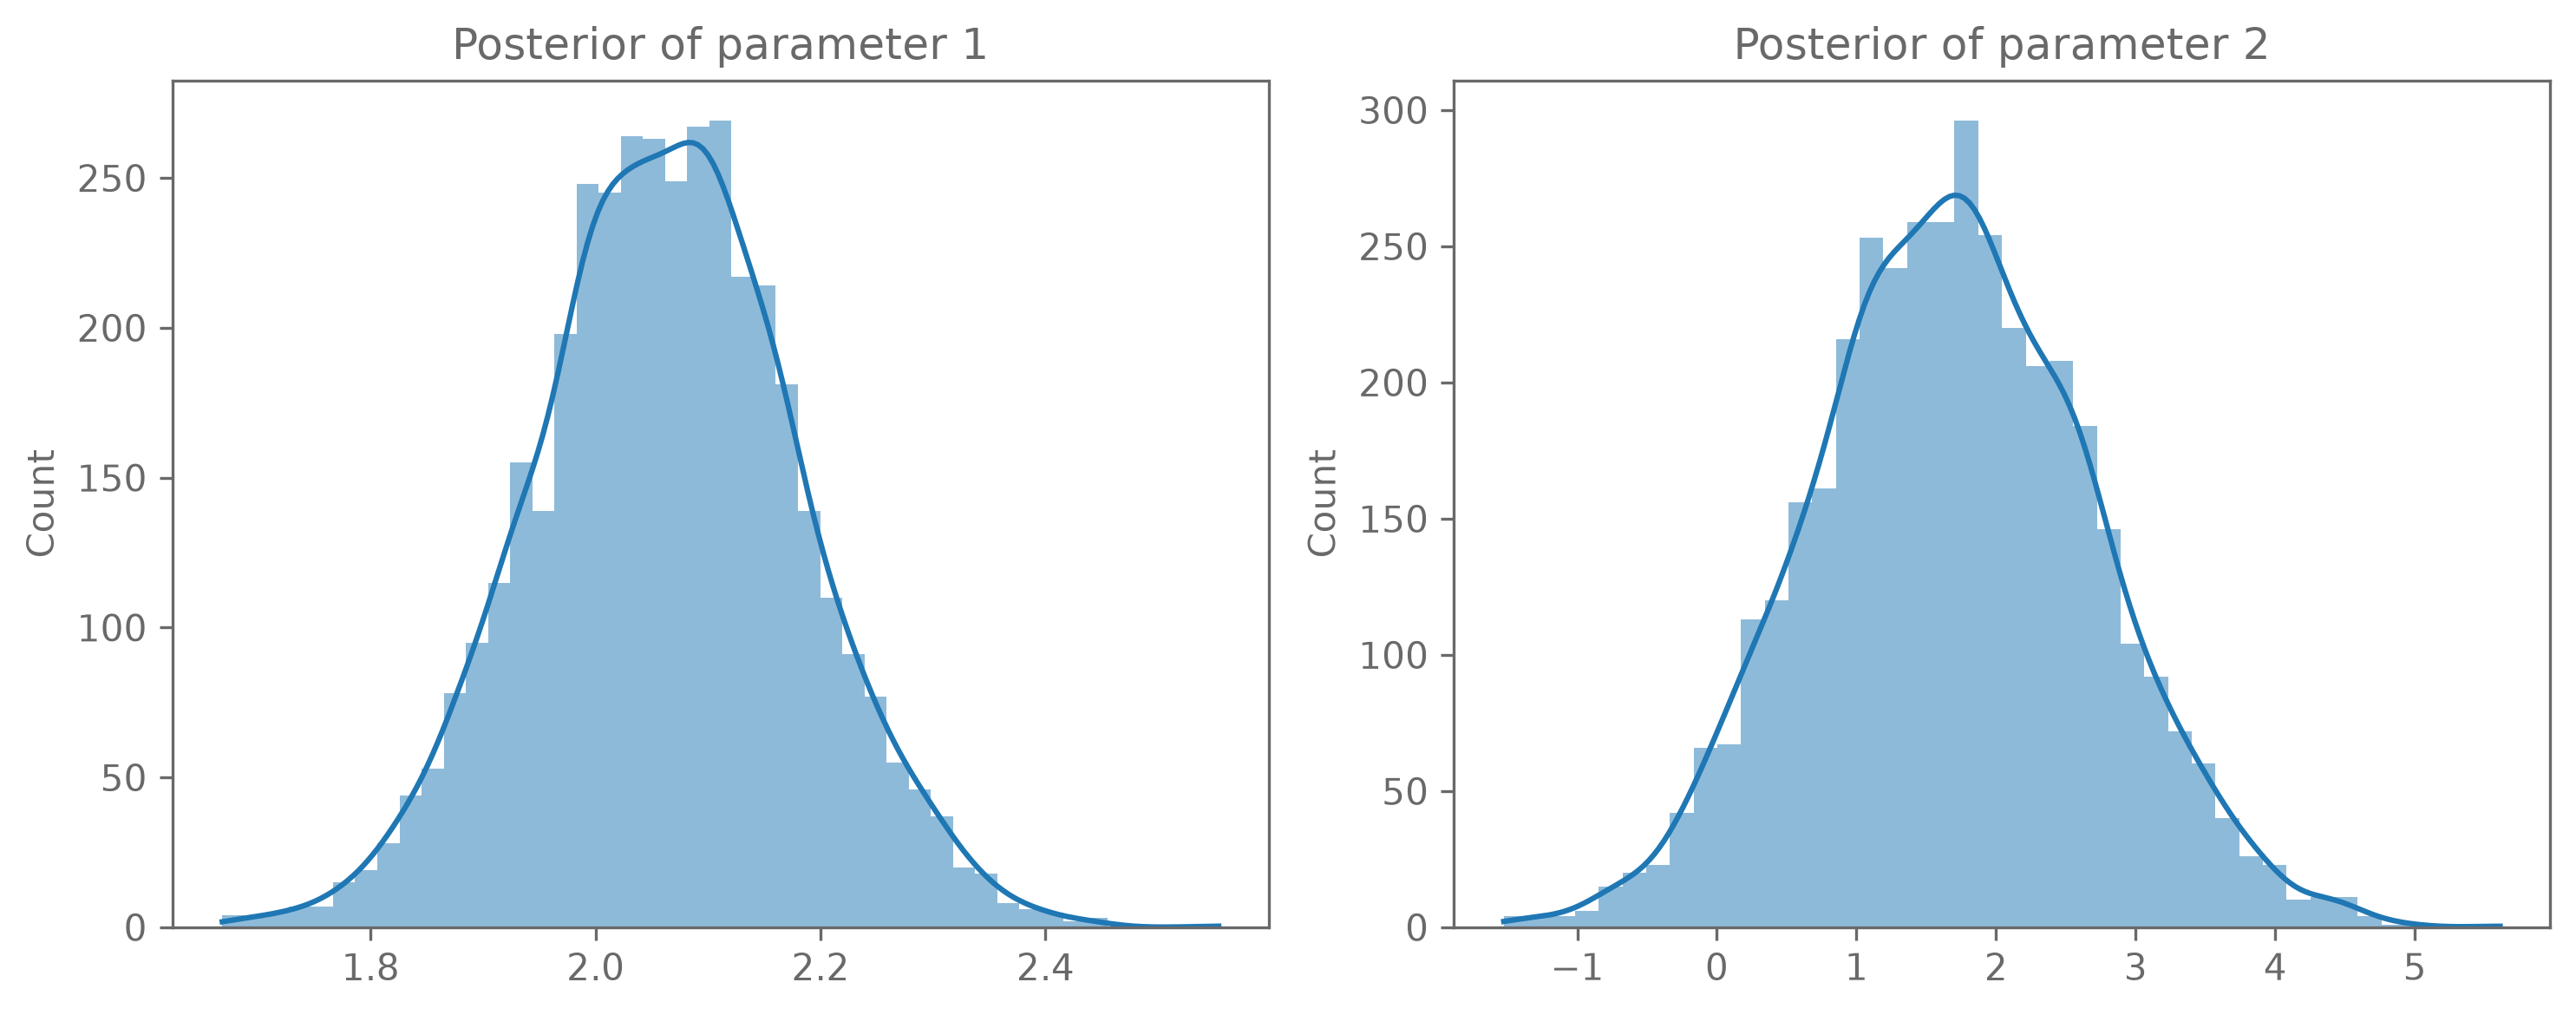

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
flat_samples = sampler.get_chain(discard=1000, thin=10, flat=True)
# shape: (N_samples, n_param)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(flat_samples[:,0], kde=True, ax=axes[0])
axes[0].set_title("Posterior of parameter 1")

sns.histplot(flat_samples[:,1], kde=True, ax=axes[1])
axes[1].set_title("Posterior of parameter 2")

plt.tight_layout()
plt.show()


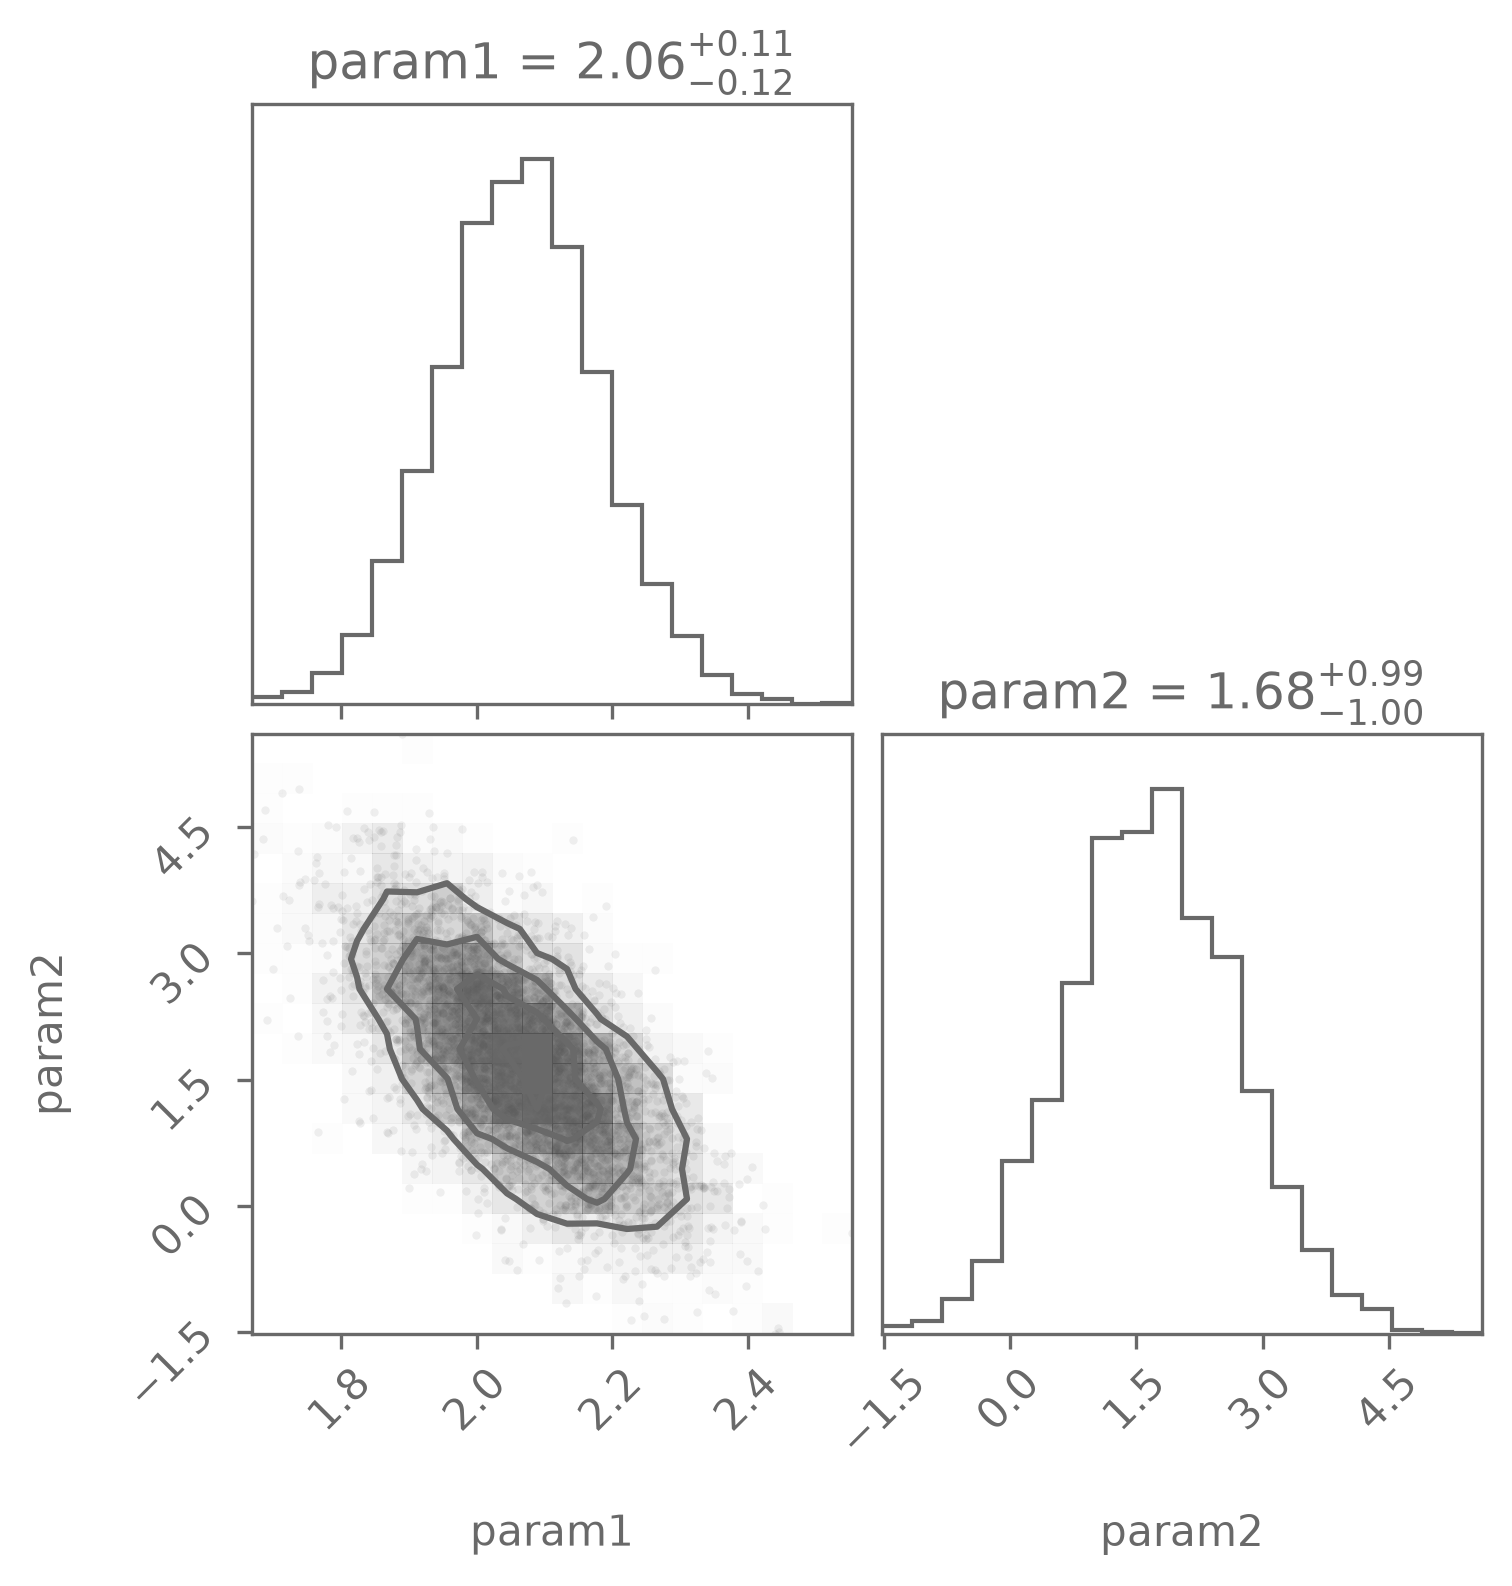

In [129]:
import corner

figure = corner.corner(
    flat_samples,
    labels=["param1", "param2"],
    show_titles=True
)


## Ex1 with new data

In [6]:
x,y,yerr=np.loadtxt("data/linear_fits/data_1.txt", unpack=True)

<ErrorbarContainer object of 3 artists>

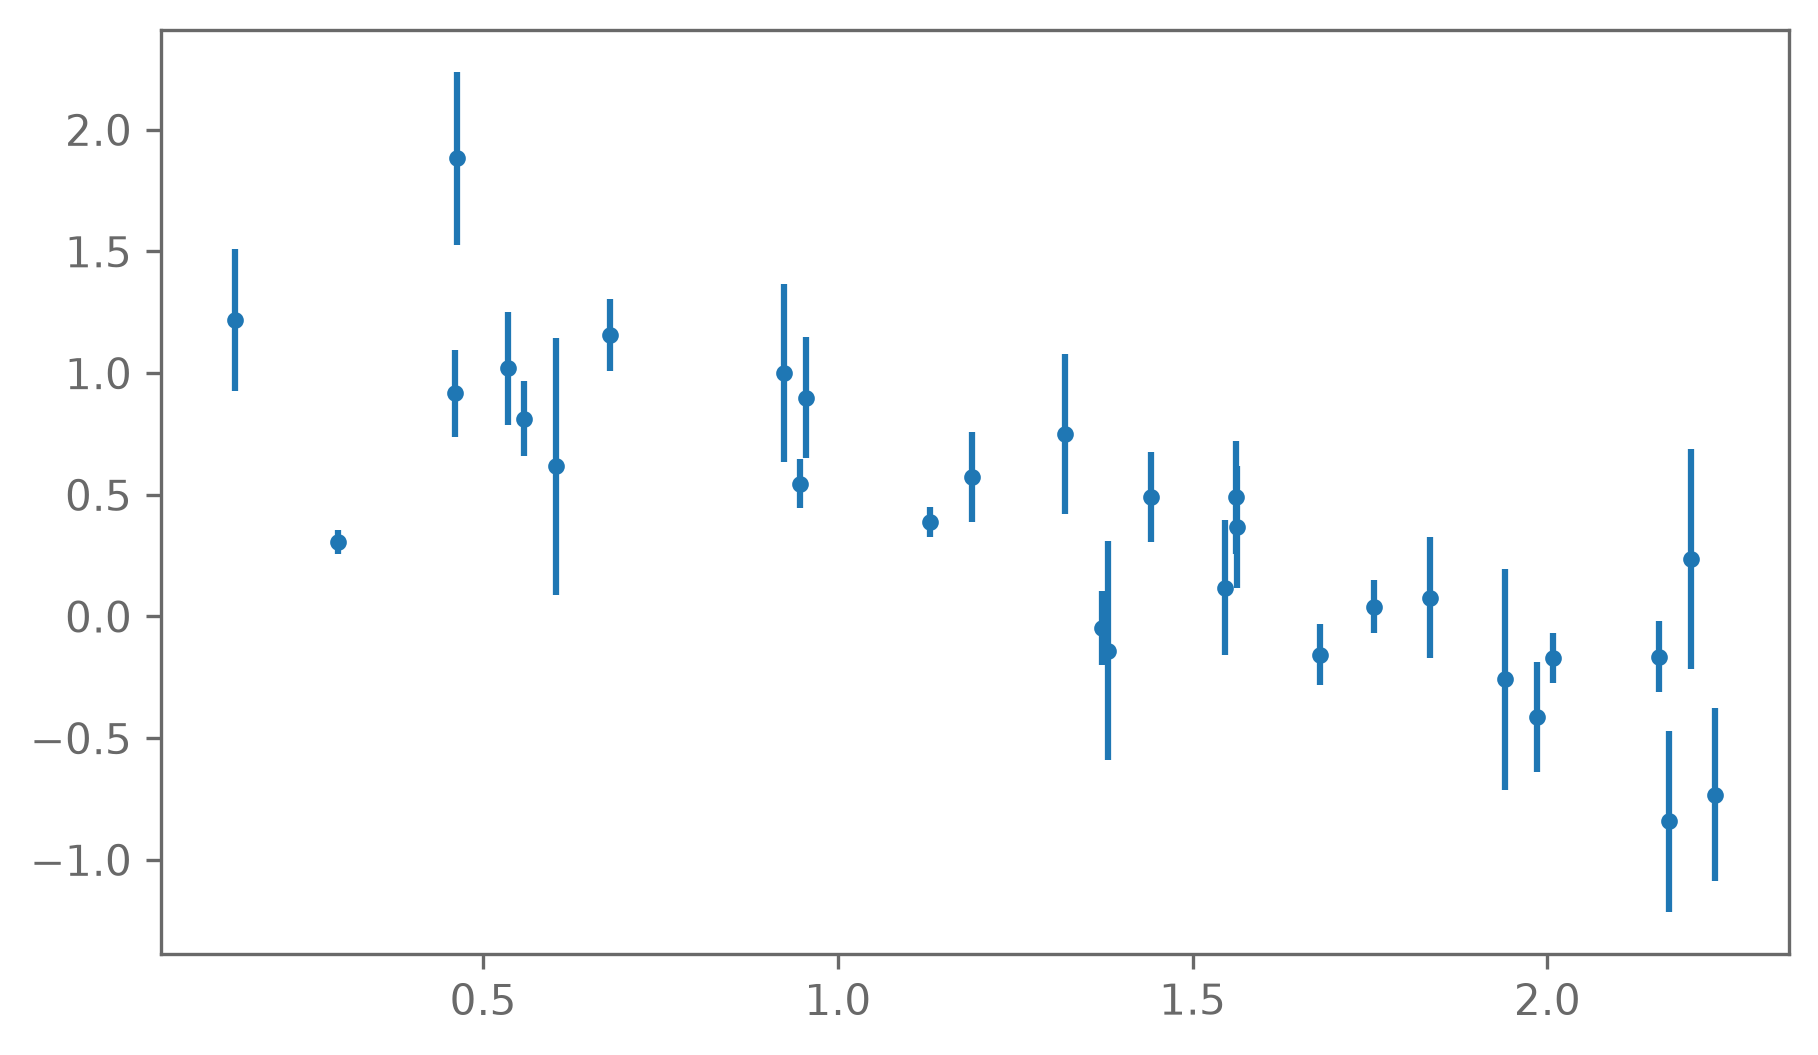

In [7]:
plt.errorbar(x,y,yerr=yerr, fmt=".")

In [12]:
def model(m,b,x):
    return m*x+b

def log_likelihood_prob_2(y,sigma_y,m,x,b):
    pred=model(m,b,x)

    logs= -0.5* (y-pred)**2 / sigma_y**2 - 0.5*np.log(2*np.pi*sigma_y**2)
    # print(logs)
    return np.sum(logs)
prior_m=scipy.stats.norm(loc=-1, scale=1) #set up function
prior_b=scipy.stats.norm(loc=1, scale=1)

def log_prior_prob_2(m,b):
    return prior_m.logpdf(m)+prior_b.logpdf(b) #.logpdf evaluates the log of the pdf at m and returns the value

def posterior_log_prob_2(x,y,sigma_y,m,b):
    return log_likelihood_prob_2(y,sigma_y, m,x,b) + log_prior_prob_2(m,b)

In [13]:
def sample_prior_2(n_sample):
    """Sample n_sample times from the prior distribution."""
    return np.vstack((prior_m.rvs(n_sample), prior_b.rvs(n_sample))).T #somehow the function otherwise won't accept it as a vector
    # bc the duo of numbers is then stored in 2 seperate arrays instead of 1 array with 2 values per random sample

# Fix the pseudo random number generator seed for reproducibility
np.random.seed(42)

# Evaluate the model at the prior sample parameters
prior_model_predictive = np.array(
    [model(*parameters, x) for parameters in sample_prior_2(n_sample=20)]
)

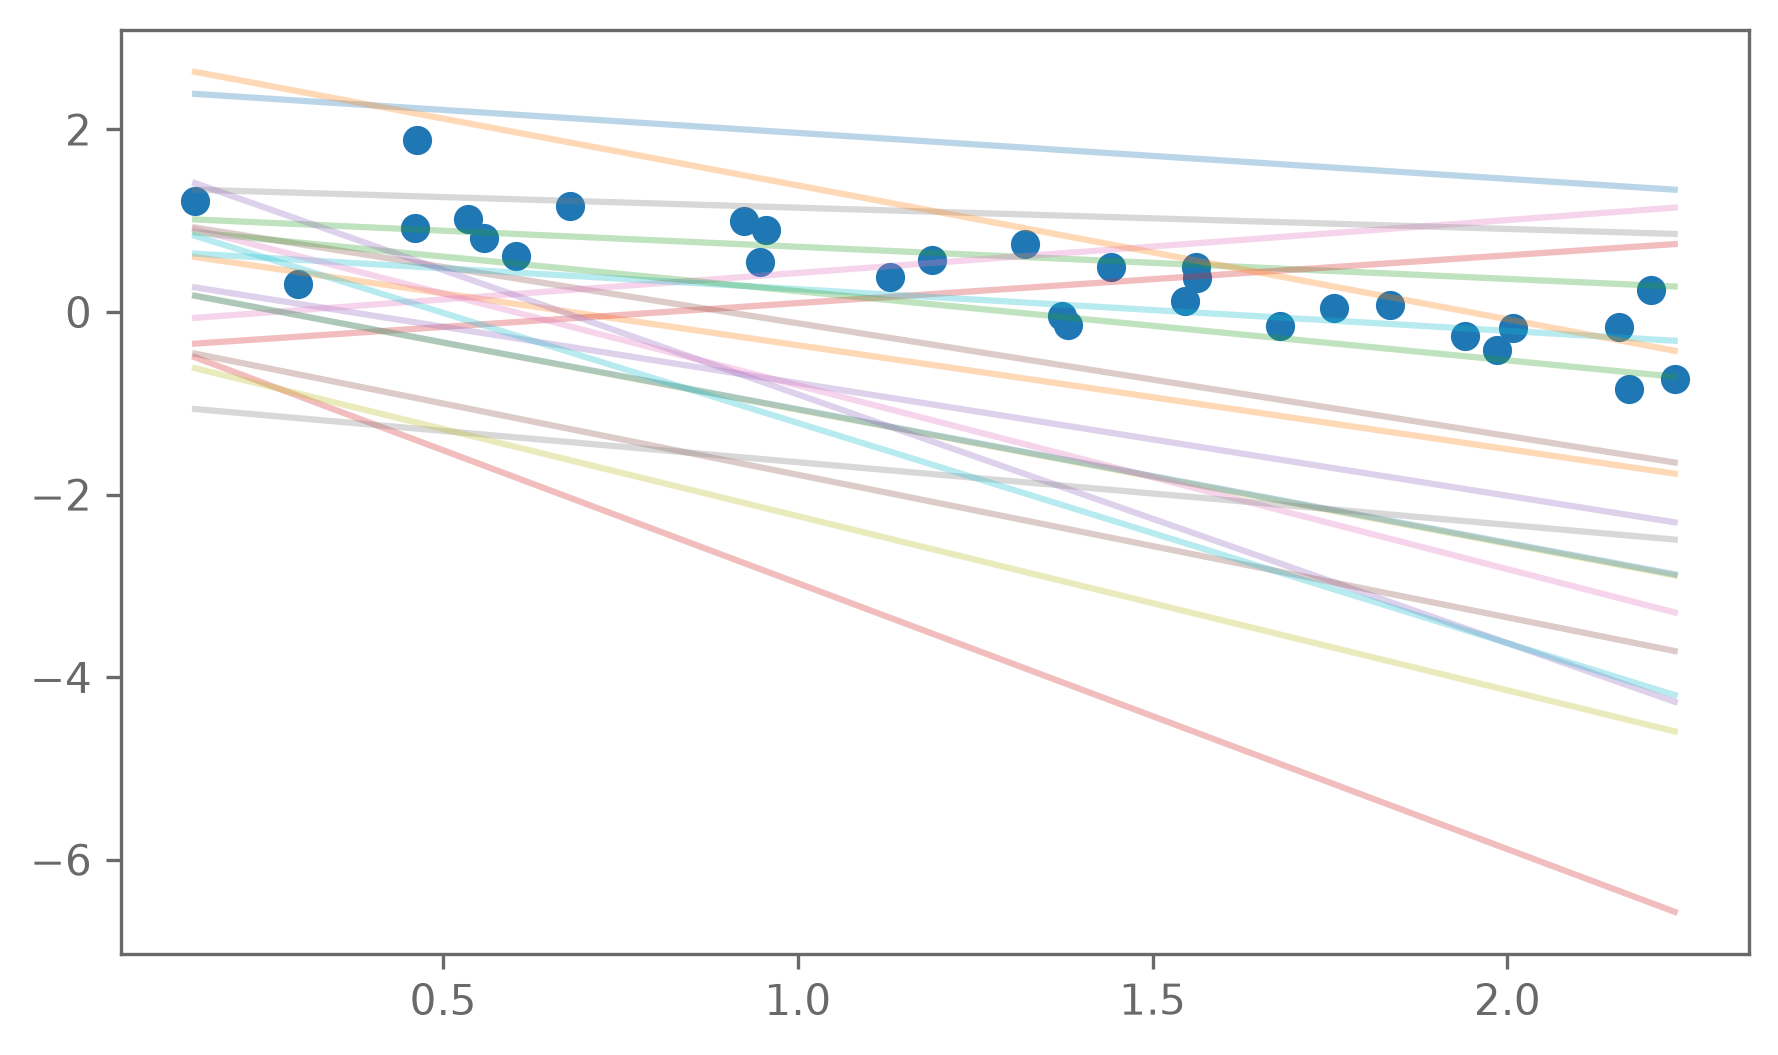

In [14]:
for i in range (0,len(prior_model_predictive)):
    plt.plot(x,prior_model_predictive[i], alpha=0.3)
plt.scatter(x,y)

In [15]:
def negative_log_posterior_prob_2(params,x,y,sigma_y):
    m,b =params
    return -1*posterior_log_prob_2(x,y,sigma_y, m,b)

MAP_result=scipy.optimize.minimize(
    fun=negative_log_posterior_prob_2,
    x0=[-3,2],
    args=(x,y,yerr)
)

In [16]:
MAP_result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 49.72848899761802
        x: [-3.616e-01  6.997e-01]
      nit: 4
      jac: [-9.537e-07 -1.431e-06]
 hess_inv: [[ 1.771e-03 -1.842e-03]
            [-1.842e-03  2.599e-03]]
     nfev: 18
     njev: 6

In [17]:
m_MAP, b_MAP = MAP_result.x
print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")


MAP results
m_MAP = -0.362, b_MAP = 0.700


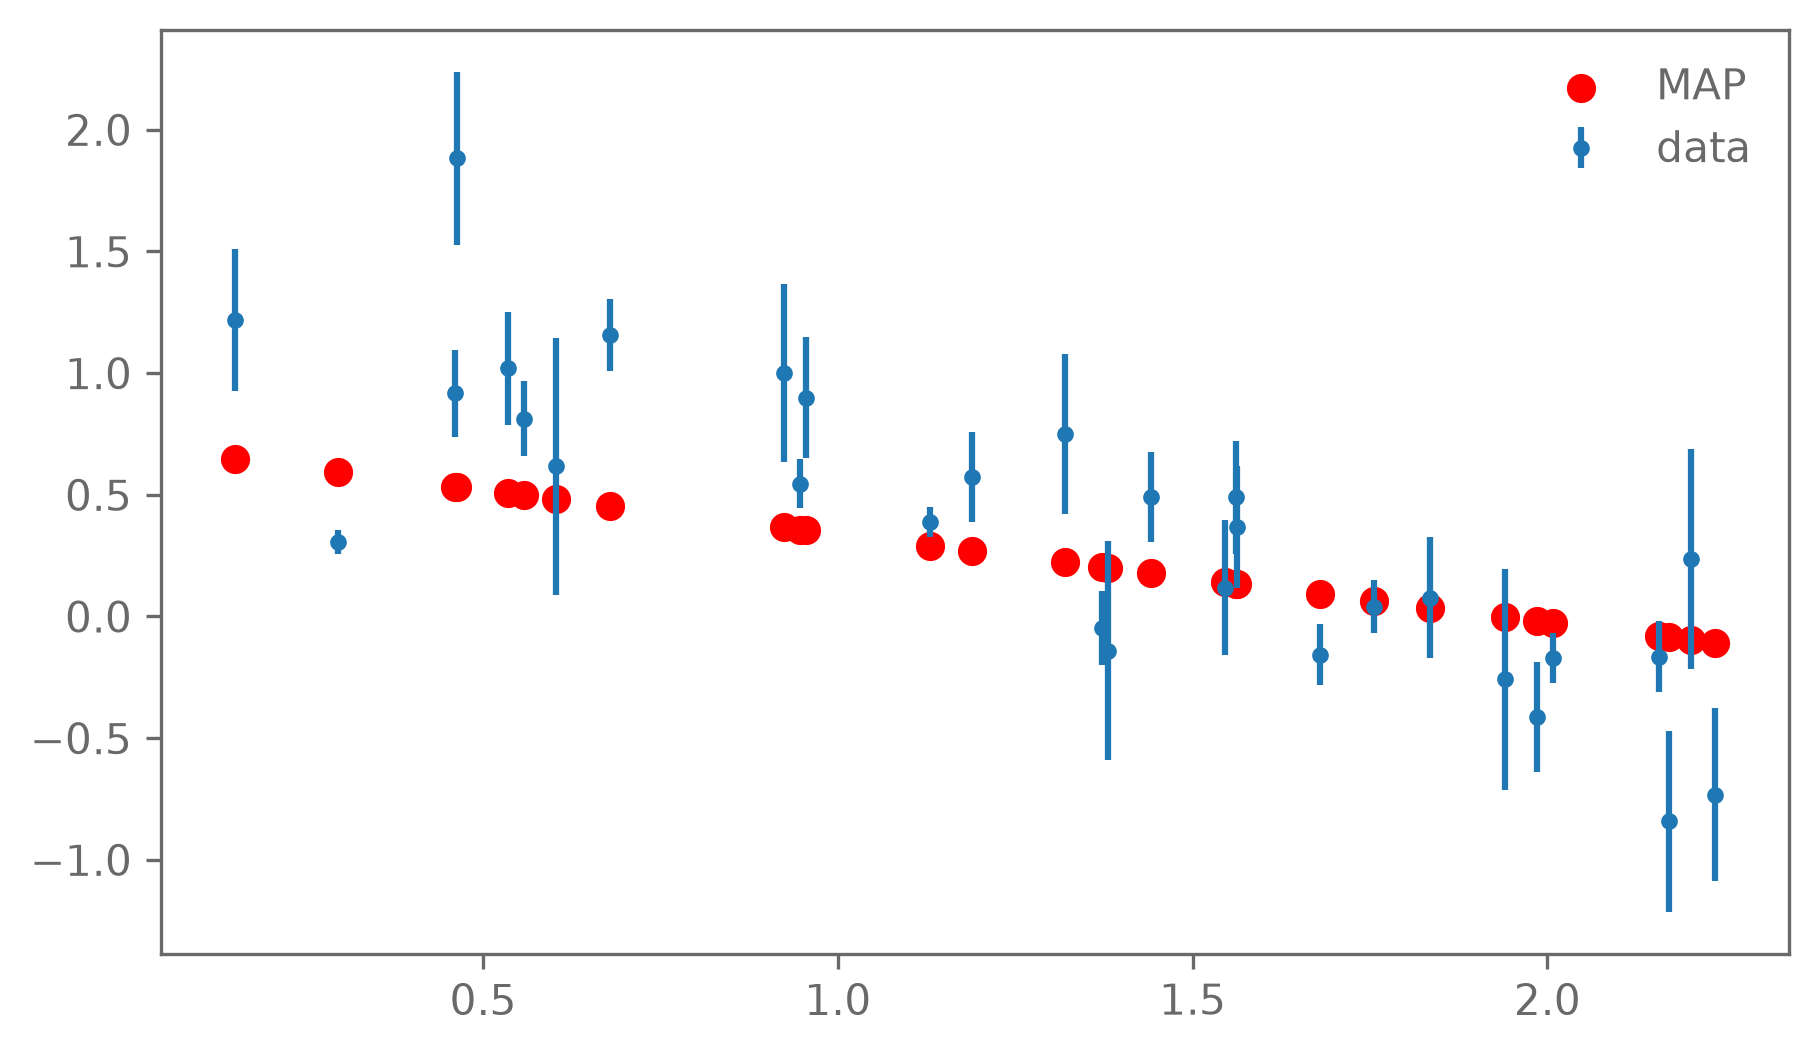

In [18]:
plt.errorbar(x,y, yerr=yerr,label="data", fmt=".")
plt.scatter(x,model(m_MAP,b_MAP,x), label="MAP", color="r")
plt.legend()

In [20]:
import emcee
# emcee passes an array of values for the sampled parameters
# This wrapper just splits the array theta into m and b
def log_posterior_wrapper_2(theta, x, sigma_y, y):
    m, b = theta
    return posterior_log_prob_2(x,y,sigma_y,m,b)
# emcee requires some extra settings to run
n_param = 2       # Number of parameter we are sampling
n_walker = 10     # Number of walkers. This just needs to be 
                  # larger than 2*n_param + 1!
n_step = 5000     # How many steps each walker will take. The number
                  # of samples will be n_walker*n_step
# The starting point for each walker
theta_init = np.array([m_MAP, b_MAP]) \
    + 0.1*np.random.normal(size=(n_walker, n_param))
sampler = emcee.EnsembleSampler(
    nwalkers=n_walker, ndim=n_param,
    log_prob_fn=log_posterior_wrapper_2,
    args=(x, yerr, y)
)
state = sampler.run_mcmc(theta_init, nsteps=n_step)

In [ ]:
print("Auto-correlation time:")
for name, value in zip(["m", "b", "f"], sampler.get_autocorr_time()): #average nr of steps before previous state "forgotten"
    print(f"{name} = {value:.1f}")

Auto-correlation time:
m = 34.1
b = 37.6


In [23]:
chain = sampler.get_chain(discard=300, thin=40, flat=True)

In [24]:
print("Posterior results (mean±std)")
print(f"m = {np.mean(chain[:,0]):.2f}±{np.std(chain[:,0]):.2f}")
print(f"b = {np.mean(chain[:,1]):.2f}±{np.std(chain[:,1]):.2f}")


Posterior results (mean±std)
m = -0.36±0.04
b = 0.70±0.05


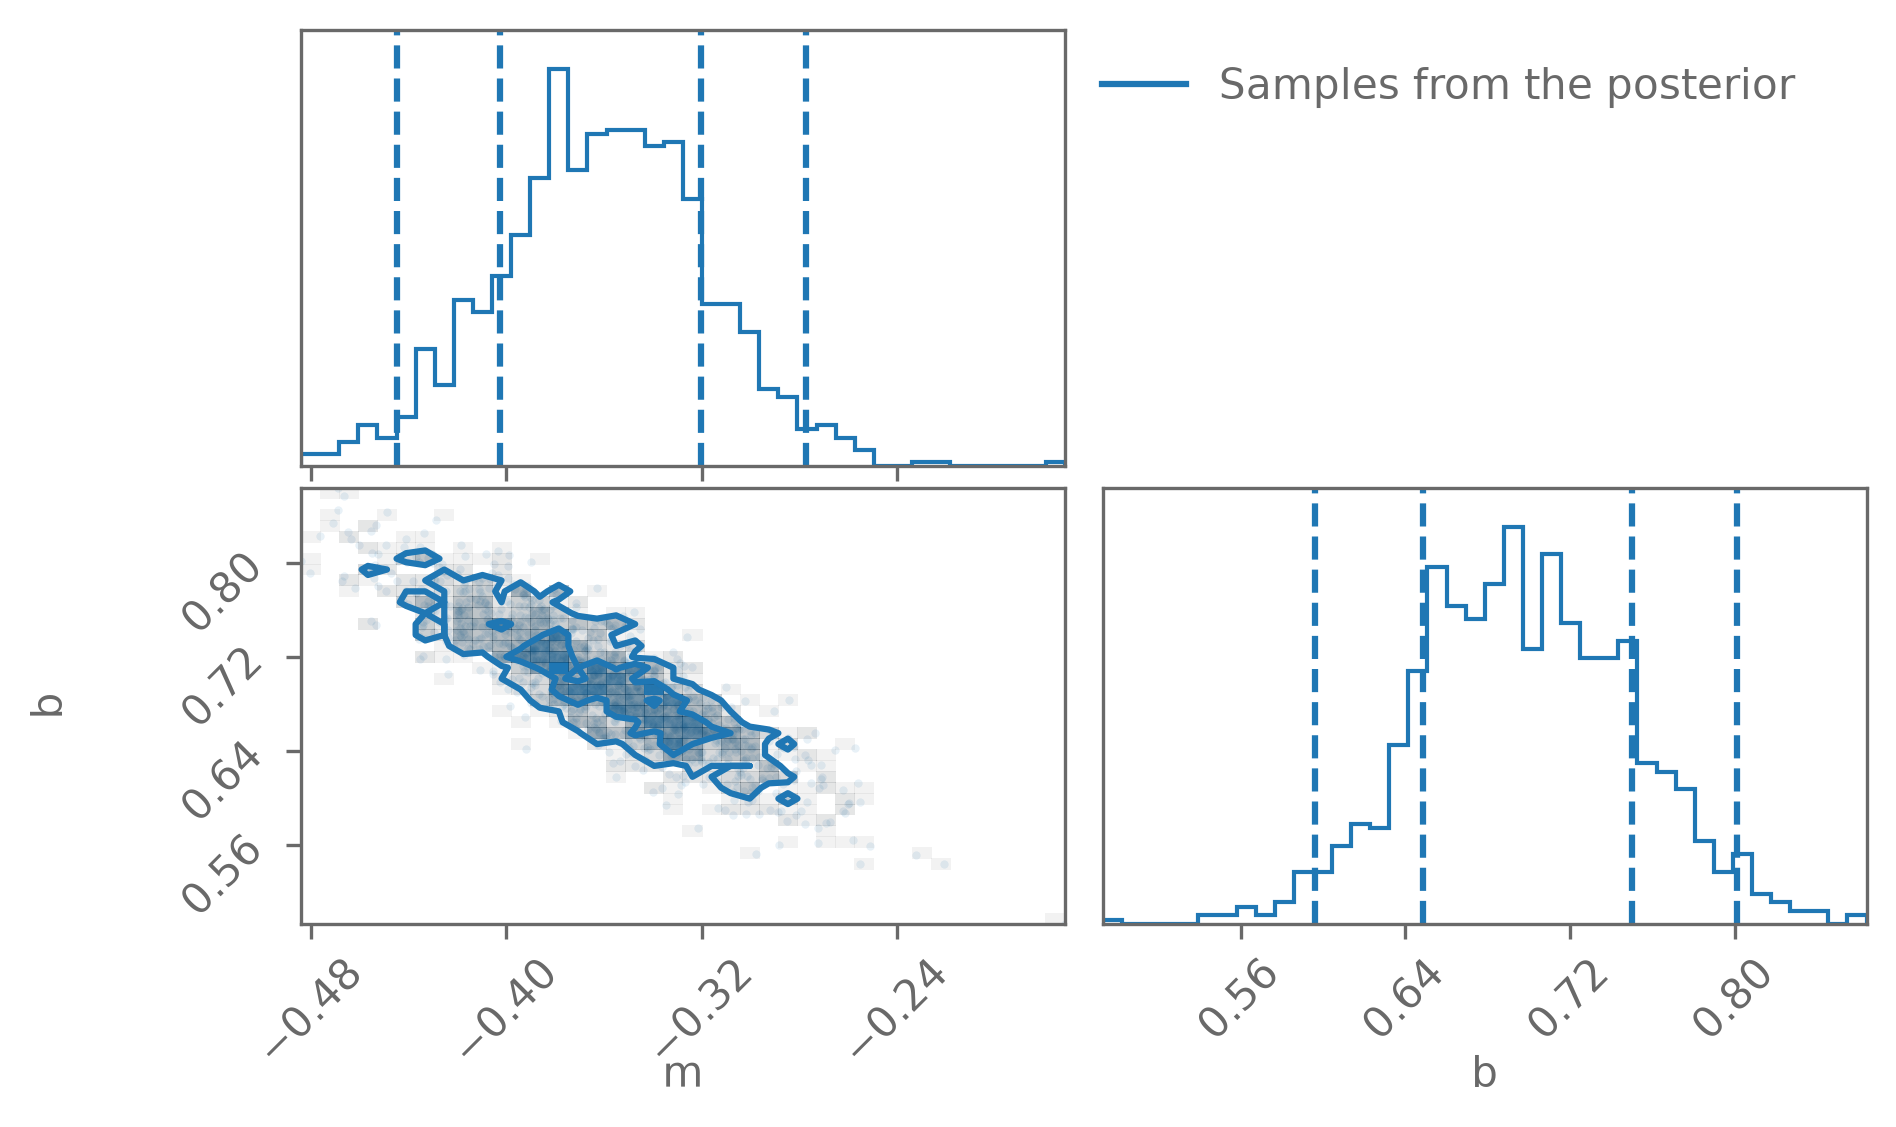

In [26]:
import corner
fig = plt.figure()
fig = corner.corner(
chain,
bins=40,
labels=["m", "b"],
color="C0",
levels=1-np.exp(-0.5*np.array([1, 2])**2), # Credible contours corresponding
# to 1 and 2 sigma in 2D
quantiles=[0.025, 0.16, 0.84, 0.975],
fig=fig
);
fig.get_axes()[0].plot([], [], c="C0", label="Samples from the posterior")
fig.get_axes()[0].legend(loc=2, bbox_to_anchor=(1, 1))



In [27]:
# Choose a small subsample of the chain for plotting purposes
chain_samples = chain[np.random.choice(chain.shape[0], size=200)]
# Evaluate the model at the sample parameters
model_predictive = np.array(
[model(*sample, x) for sample in chain_samples]
)
model_quantiles = np.quantile(
model_predictive, q=[0.025, 0.16, 0.84, 0.975], axis=0
)


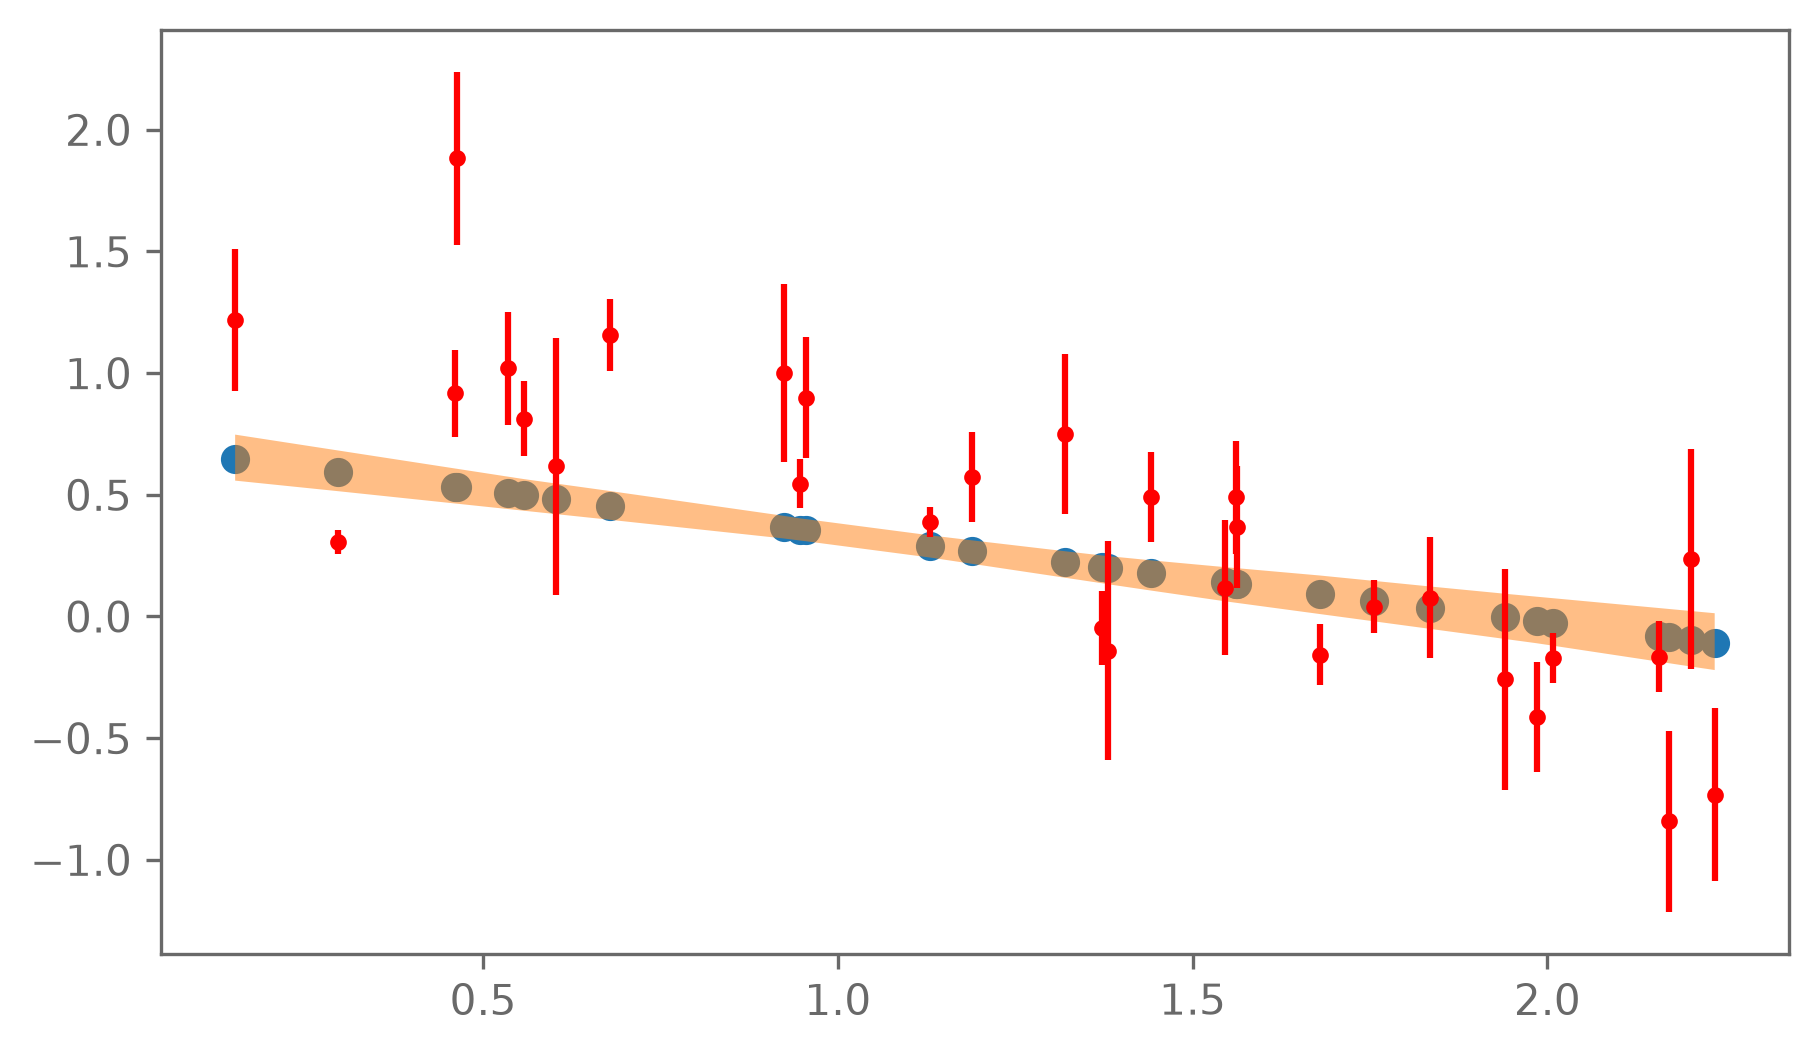

In [33]:
plt.scatter(x,model(m_MAP,b_MAP,x), label="MAP")
plt.errorbar(x,y,yerr=yerr,fmt=".",label="data", color="r")
plt.fill_between(x,model_quantiles[0], model_quantiles[-1], alpha=0.5)

In [36]:
def plot_linear_data_set(x, y, y_err=None):
    """Plot linear data set and format the plot."""
    fig, ax = plt.subplots(1, 1)

    if y_err is not None:
        ax.errorbar(x, y, y_err, fmt=".", label="Data")
    else:
        ax.plot(x, y, marker=".", linestyle="none", label="Data")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="upper left")

    return fig, ax

/tmp/ipykernel_983/2310205853.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  violin_plots = ax.violinplot(


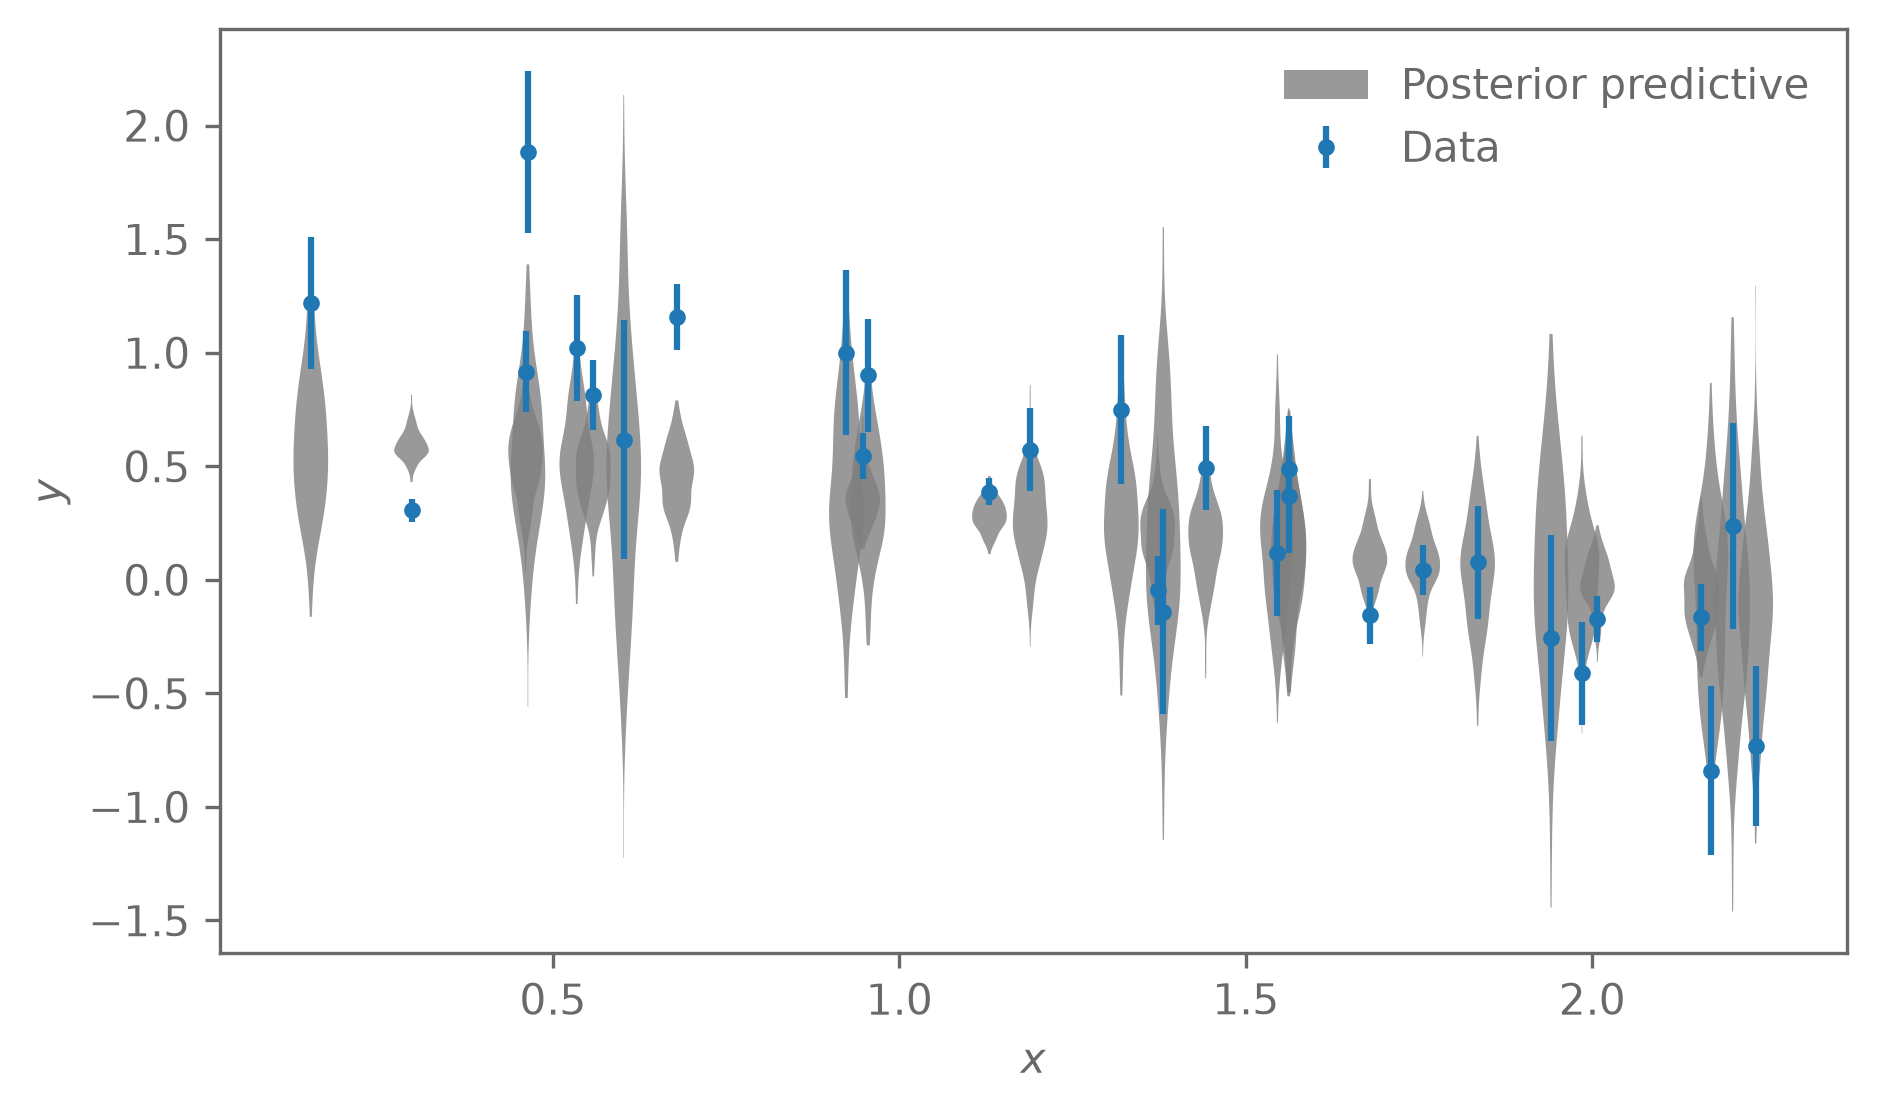

In [39]:
# Because we have a Gaussian likelihood with variance \sigma_y^2, we can sample
# from the posterior predictive distribution by adding Gaussian noise with
# variance \sigma_y^2 to the model prediction samples
posterior_predictive = \
    model_predictive + yerr*np.random.normal(size=model_predictive.shape)
_, ax = plot_linear_data_set(x, y, yerr)

violin_plots = ax.violinplot(
    dataset=posterior_predictive,
    positions=x, widths=0.05,
    vert=True, showmeans=False, showextrema=False,
)
for body in violin_plots["bodies"]:
    body.set(color="grey", alpha=0.8, edgecolor=None)
body.set(label="Posterior predictive")

ax.legend();

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x70d009a05950>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x70d009a07ed0>,
 'cmins': <matplotlib.collections.LineCollection at 0x70d008688050>,
 'cbars': <matplotlib.collections.LineCollection at 0x70d008688190>}

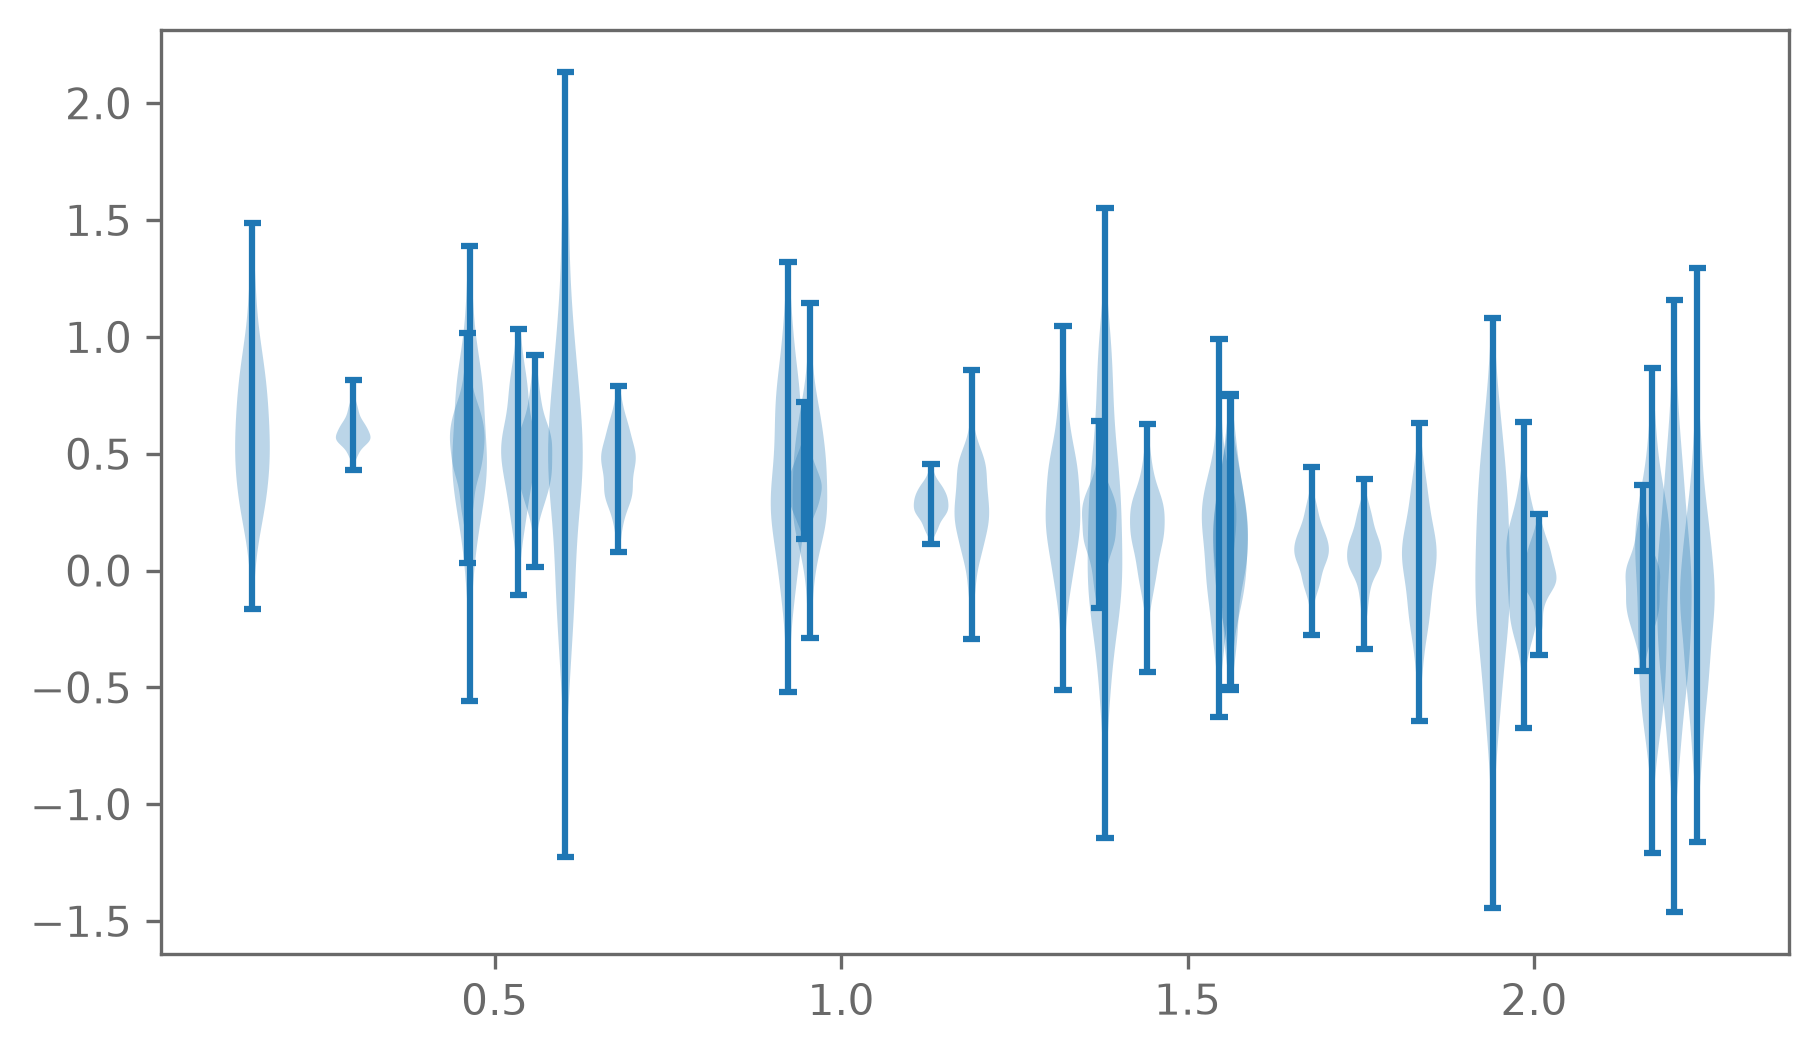

In [58]:
plt.violinplot(posterior_predictive,positions=x,widths=0.05, orientation="vertical",showmeans=False,showextrema=True)

## New likelihood with scaled error

In [73]:
def plot_data(x, y, y_err, models=None, subtract_y=None,
              axis_labels=["$x$", "$y$"], **data_kwargs):
    """
    Create a set of summary plots for a list of "models."
    The types of plots are inferred from the dictionary
    describing the model.

    For example, if `violin_samples` is a key in the dictionary
    of one of the models, then a violinplot will be made, e.g.
    to visualize the posterior predictive distribution. 
    
    Parameters:
    -----------
    x : np.ndarray
        x-values of the data
    y : np.ndarray
        y-values of the data
    y_err : np.ndarray or float
        uncertainty on the y-values of the data
    models : list
        A list of models to plot information for. Each entry of this list
        is a dictionary that specifies information about the model. Below, we include
        the specification of what can be in this dictionary.
    subtract_y : np.ndarray or float
        An array of values or a single value to subtract 
        from all values of the data (a constant offset)
    axis_labels : list
        a list of strings, uses only the first two entries. The first for
        the x-axis the second for labeling the y-axis
    data_kwargs : dict
        a dictionary of keyword arguments that get passed to plotting functions
        like matplotlib.pyplot.plot.
        
    Returns:
    --------
    fig : plt.figure object
    ax : plt.axis object
    """

    
    fig, ax = plt.subplots()

    data_kwargs = {**data_kwargs}
    if "ls" not in data_kwargs and "linestyle" not in data_kwargs:
        data_kwargs["linestyle"] = "none"
    if "marker" not in data_kwargs:
        data_kwargs["marker"] = "."

    if subtract_y is None:
        subtract_y = np.zeros_like(y)
    ax.errorbar(x, y-subtract_y, y_err, **data_kwargs, label="Data")

    # set the width of the violin plots for the
    # posterior predictive plots
    def default_violin_width(x, scale=1.5, max_frac=0.1):
        """Violin width from mean x-spacing; overlap in clusters is tolerated."""
        x = np.unique(x)
        if x.size < 2:
            return 0.5
        span = x[-1] - x[0]
        return min(scale * span / (x.size - 1), max_frac * span)
        
    # loop 
    if models is not None:
        for model_def in models:
            if "lower" in model_def:
                ax.fill_between(
                    model_def["x"],
                    model_def["lower"], model_def["upper"],
                    **model_def.get("style", {})
                )
            elif "y_err" in model_def:
                ax.errorbar(
                    model_def["x"], model_def["y"], model_def["y_err"],
                    **model_def.get("style", {})
                )
            elif "violin_samples" in model_def:
                style = dict(model_def.get("style", {}))
                # pull apart what is a kwarg to ax.violinplot
                # and what has to be included separately
                # this is annoying because matplotlib's violinplots
                # are annoying.
                vp_kwargs = {k: style.pop(k) for k in
                             ("widths", "showmeans", "showmedians",
                              "showextrema", "quantiles", "points", "bw_method")
                             if k in style}
                vp_kwargs = {"showmeans": False, "showextrema": False, **vp_kwargs}
                vp_kwargs.setdefault("widths", default_violin_width(model_def["x"]))
                violin_plots = ax.violinplot(
                    dataset=model_def["violin_samples"],
                    positions=model_def["x"], **vp_kwargs
                )                
                for body in violin_plots["bodies"]:
                    body.set(**style)
                    if "label" in style:
                        del style["label"]

            else:
                ax.plot(
                    model_def["x"], model_def["y"],
                    **model_def.get("style", {})
                )

    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.legend(frameon=False)

    return fig, ax



def analyse_data(data,
                 log_posterior_fn, model_fn, predict_fn, ppd_test_statistic_fn=None,
                 param_names=None,
                 derived_parameter_fn=None, derived_parameter_names=[],
                 derived_parameter_true=[],
                 theta_true=None,
                 theta_init=None, theta_init_std=None,
                 plot=True, model_x=None,
                 n_step_emcee=5000, n_ppd=500):
    """
    Implement a Bayesian workflow on 1-dimensional data that contains
    an independent variable (x), a dependent variable (y) and uncertainty
    on the measured dependent variable (y_err). 

    It first calculaes a maximum a posteriori value for the parameters using scipy.optimize.
    
    Then it uses Markov chain Monte Carlo to produce samples distributed according
    to the posterior distribution on the parameters of the model (using the 
    emcee package). 

    Subsequently, it calculates model predictive and posterior predictive distributions,
    plots them, and performs a posterior predictive check if there is a function
    that is supplied to do so (`ppd_test_statistic`, discussed in detail Week 7).

    Parameters:
    -----------
    log_posterior_fn : Callable function
        A callable function that takes in (theta, x, y_err, y) where
        theta is the list of free parameters.
    model_fn : Callable function
        A callable function that takes in (theta, x) as parameters
        and returns an estimate of y. 
    predict_fn : Callable function
        A callable function that takes in (theta, x, y_err, y) and produces
        predicted data from that model (simulates data from the likelihood, given
        a set of parameters).
    ppd_test_statistic_function : Callable function
        Takes in (y, theta, x, sigma_y) and produces a single summary statistic
        that can be used to compare replicated (posterior predictive) data with real data.
    derived_parameter_fn : Callable function
        If there are interesting parameters that are deterministically derived from the
        parameters that we sample, then they are defined here.
    derived_parameter_names : list
        A list of the names of the derived parameters output from `derived_parameter_fn`
    derived_parameter_true : list
        A list of the *true* derived parameters (if known)
    theta_true : np.ndarray, or list
        A list of the true parameters that were sampled (if known)
    theta_init : np.ndarray
        The initial values for the sampled parameters at the start of MCMC sampling
    theta_std : np.ndarray
        We can initialize the sampler around theta_init with some standard deviation.
    plot : bool
        True to make summary plots. False to not make them. 
    n_step_emcee : int, default=5000
        number of MCMC steps to take
    n_ppd : int, default=500
        number of posterior samples on which to calculate ppd_test_statistic

    Returns:
    --------
    results : dict
        A results dictionary containing samples, true values, posterior fit information
        and (if supplied) posterior predictive checking information.
    """

    x, y, sigma_y = data["x"], data["y"], data["y_err"]

    # MCMC initialization
    if theta_init is None:
        theta_init = theta_true
    theta_init = np.array(theta_init)

    if theta_init_std is None:
        theta_init_std = 0.1*theta_init
        theta_init_std[theta_init_std == 0.0] = 0.1

    # names of parameters
    if param_names is None:
        param_names = [f"p_{i}" for i in range(theta_init.size)]

    if model_x is None:
        model_x = x

    if theta_true is not None:
        true_model_plot_def = [dict(
            x=model_x, y=model_fn(theta_true, model_x),
            style=dict(color="black", ls="--", label="True model")
        )]
    else:
        true_model_plot_def = []

    # Find the MAP
    def negative_log_posterior(theta, x, sigma_y, y):
        return -log_posterior_fn(theta, x, sigma_y, y)

    MAP_result = scipy.optimize.minimize(
        fun=negative_log_posterior,
        x0=theta_init,
        args=(x, sigma_y, y)
    )
    theta_MAP = MAP_result.x

    print("MAP results")
    for name, theta in zip(param_names, theta_MAP):
        print(f"{name}_MAP = {theta}")


    # Sample posterior with emcee

    # emcee requires some extra settings to run
    n_param = len(theta_init) # Number of parameter we are sampling
    n_walker = 3*n_param      # Number of walkers. This just needs to be larger than 2*n_param + 1
    n_step = n_step_emcee     # How many steps each walker will take. The number of samples will be n_walker*n_step

    # The starting point for each walker
    theta_init = theta_init + theta_init_std*np.random.normal(size=(n_walker, n_param))

    # compute derived parameters while sampling
    if derived_parameter_fn is not None:
        log_posterior_wrapper = lambda *args: (log_posterior_fn(*args), derived_parameter_fn(args[0]))
    else:
        log_posterior_wrapper = log_posterior_fn
    sampler = emcee.EnsembleSampler(
        nwalkers=n_walker, ndim=n_param,
        log_prob_fn=log_posterior_wrapper,
        args=(x, sigma_y, y)
    )
    state = sampler.run_mcmc(theta_init, nsteps=n_step, progress=True)

    # The samples will be correlated, this checks how correlated they are
    # We will discuss this once we come to MCMC methods
    integrated_autocorr_time = sampler.get_autocorr_time(quiet=True)
    print("Auto-correlation time of chain:")
    for name, value in zip(param_names, integrated_autocorr_time):
        print(f"{name} = {value:.1f}")

    max_autocorr_time = max(integrated_autocorr_time)

    # We need to discard the beginning of the chain (a few auto-correlation times)
    # to get rid of the initial conditions
    burn_in_config = dict(
        discard=int(5*max_autocorr_time),
        thin=int(max_autocorr_time/2),
        flat=True
    )
    chain = sampler.get_chain(
        **burn_in_config
    )

    # Make predictive distributions
    # Choose a small subsample of the chain for plotting purposes
    chain_samples = chain[np.random.choice(chain.shape[0], size=n_ppd)]
    # Evaluate the model at the sample parameters
    model_predictive = np.array(
        [model_fn(sample, model_x) for sample in chain_samples]
    )
    model_quantiles = np.quantile(
        model_predictive, q=[0.025, 0.16, 0.84, 0.975], axis=0
    )

    posterior_predictive = np.array(
        [predict_fn(sample, x, sigma_y) for sample in chain_samples]
    )
    posterior_predictive_quantiles = np.quantile(
        posterior_predictive, q=[0.025, 0.16, 0.84, 0.975], axis=0
    )

    if ppd_test_statistic_fn is not None:
        T_rep = np.array(
            [ppd_test_statistic_fn(y_rep, sample, x, sigma_y)
             for y_rep, sample in zip(posterior_predictive, chain_samples)]
        )
        T_data = np.array(
            [ppd_test_statistic_fn(y, sample, x, sigma_y)
             for sample in chain_samples]
        )
        goodness_of_fit_pte = np.sum((T_rep - T_data) > 0)/len(T_rep)

        print(f"Posterior predictive p-value: {goodness_of_fit_pte:.2g} "
              f"(T_rep = {np.mean(T_rep):.2g}±{np.std(T_rep):.2g}, "
              f"T_data = {np.mean(T_data):.2g}±{np.std(T_data):.2g})"
        )

    if derived_parameter_fn is not None:
        blobs = sampler.get_blobs(
            **burn_in_config
        )
        if blobs.ndim == 1:
            blobs = blobs.reshape(-1, 1)
        chain = np.concatenate((chain, blobs), axis=-1)

    print("Posterior results (mean±std)")
    for i, name in enumerate(param_names + derived_parameter_names):
        print(f"{name} = {np.mean(chain[:,i]):.2g}±{np.std(chain[:,i]):.2g}")

    if plot:
        # Make a corner plot
        fig = plt.figure()
        fig = corner.corner(
            chain,
            bins=40,
            labels=param_names + derived_parameter_names,
            truths=theta_true + derived_parameter_true,
            levels=1-np.exp(-0.5*np.array([1, 2])**2), # Credible contours corresponding to 1 and 2 sigma in 2D
            quantiles=[0.025, 0.16, 0.84, 0.975],
            fig=fig
        )
        plot_data(
            x=x, y=y, y_err=sigma_y,
            models=[
                dict(x=model_x, y=model_fn(theta_MAP, model_x),
                    style=dict(color="C2", label="MAP model")),
                
                dict(x=model_x, lower=model_quantiles[0], upper=model_quantiles[-1],
                    style=dict(color="C1", alpha=0.5, label="Model predictions")),
                dict(x=model_x, lower=model_quantiles[1], upper=model_quantiles[-2],
                    style=dict(color="C1", alpha=0.5)),
                dict(x=x, violin_samples=posterior_predictive,
                     style=dict(color="grey", alpha=0.5, label="Posterior predictions")),
            ] + true_model_plot_def,
            marker=".", linestyle="none"
        )
        # plot our posterior predictive test statistic
        if ppd_test_statistic_fn is not None:
            fig = plt.figure(figsize=(6, 6))
            gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], height_ratios=[1, 2],
                                  hspace=0.05, wspace=0.05)
            ax = fig.add_subplot(gs[1, 0])
            ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
            ax_right = fig.add_subplot(gs[1, 1], sharey=ax)
        
            lims = [min(T_data.min(), T_rep.min()), max(T_data.max(), T_rep.max())]
            # edges = np.linspace(*lims, bins + 1)
        
            ax.scatter(T_data, T_rep, s=5, alpha=0.5)
            ax.plot(lims, lims, "k--", lw=1, label="$y = x$")
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            ax.set_xlabel(r"$T(y, \theta)$")
            ax.set_ylabel(r"$T(y_\mathrm{rep}, \theta)$")
            ax.legend(frameon=False, loc="upper left")
        
            ax_top.hist(T_data, bins='auto', alpha=0.5)
            ax_right.hist(T_rep, bins='auto', alpha=0.5, orientation="horizontal")
            ax_top.tick_params(labelbottom=False)
            ax_right.tick_params(labelleft=False)
            ax_top.set_title(f"$p = {goodness_of_fit_pte:.2g}$")
            

    return dict(
        MAP=theta_MAP,
        PPD=posterior_predictive,
        TPD=model_predictive,
        PPD_params=chain_samples,
        chain=chain
    )
def model(theta, x):
    m, b = theta
    return m*x + b

In [76]:
def log_likelihood_true(theta, x, sigma_y, y):
    m, b, f = theta
    prediction = model([m, b], x)
    sigma = sigma_y + f*prediction**2
    n = len(y)
    return (-0.5 * np.sum((y - prediction)**2/sigma**2)   # Exponent
            -0.5 * np.sum(np.log(2*np.pi*sigma**2))       
)
def log_prior(theta):
    m, b = theta
    mu_m = -1
    mu_b = 1
    sigma_m = 1
    sigma_b = 1.2
    return (
        -0.5*(m-mu_m)**2/sigma_m**2      # m exponent
        -0.5*(b-mu_b)**2/sigma_b**2      # b exponent
        - 0.5*np.log(2*np.pi*sigma_m**2) # Normalisation
        - 0.5*np.log(2*np.pi*sigma_b**2) # Normalisation
    )

def log_prior_true(theta):
    m, b, f = theta
    mu_f = 0.5
    sigma_f = 1
    # Normalisation
    return log_prior([m, b]) - 0.5*(f - mu_f)**2/sigma_f**2

def log_posterior_true(theta, x, sigma_y, y):
    return log_likelihood_true(theta, x, sigma_y, y) + log_prior_true(theta)
def predict_true(theta, x, sigma_y):
    m, b, f = theta
    mu = model([m, b], x)
    sigma = sigma_y + f*mu**2
    return np.random.normal(loc=mu, scale=sigma)


MAP results
m_MAP = -0.7355425584965917
b_MAP = 1.2885817199053355
f_MAP = 0.29532331062475015


100%|██████████| 5000/5000 [00:00<00:00, 6435.65it/s]


Auto-correlation time of chain:
m = 54.2
b = 53.2
f = 51.8
Posterior results (mean±std)
m = -0.73±0.1
b = 1.3±0.17
f = 0.4±0.19


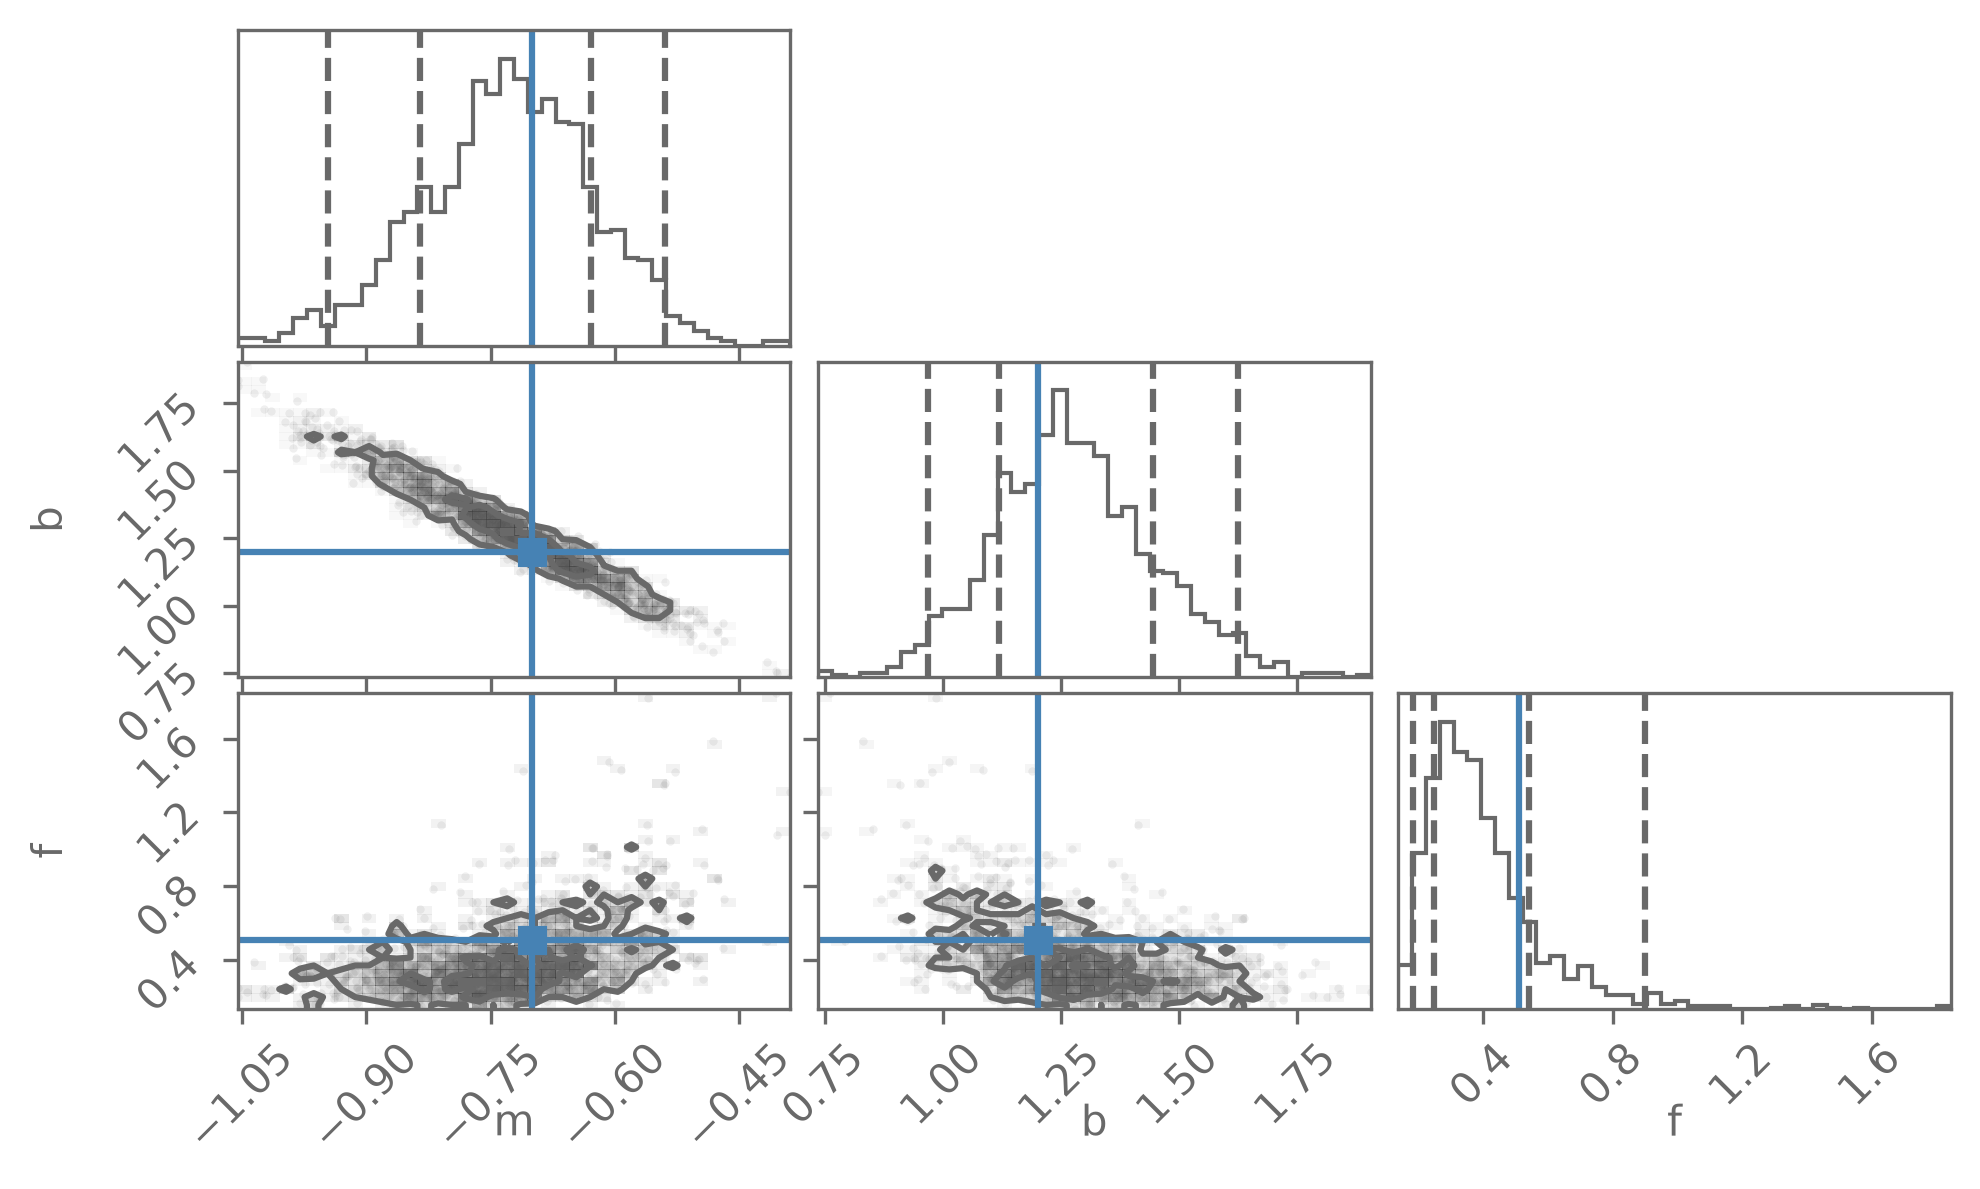

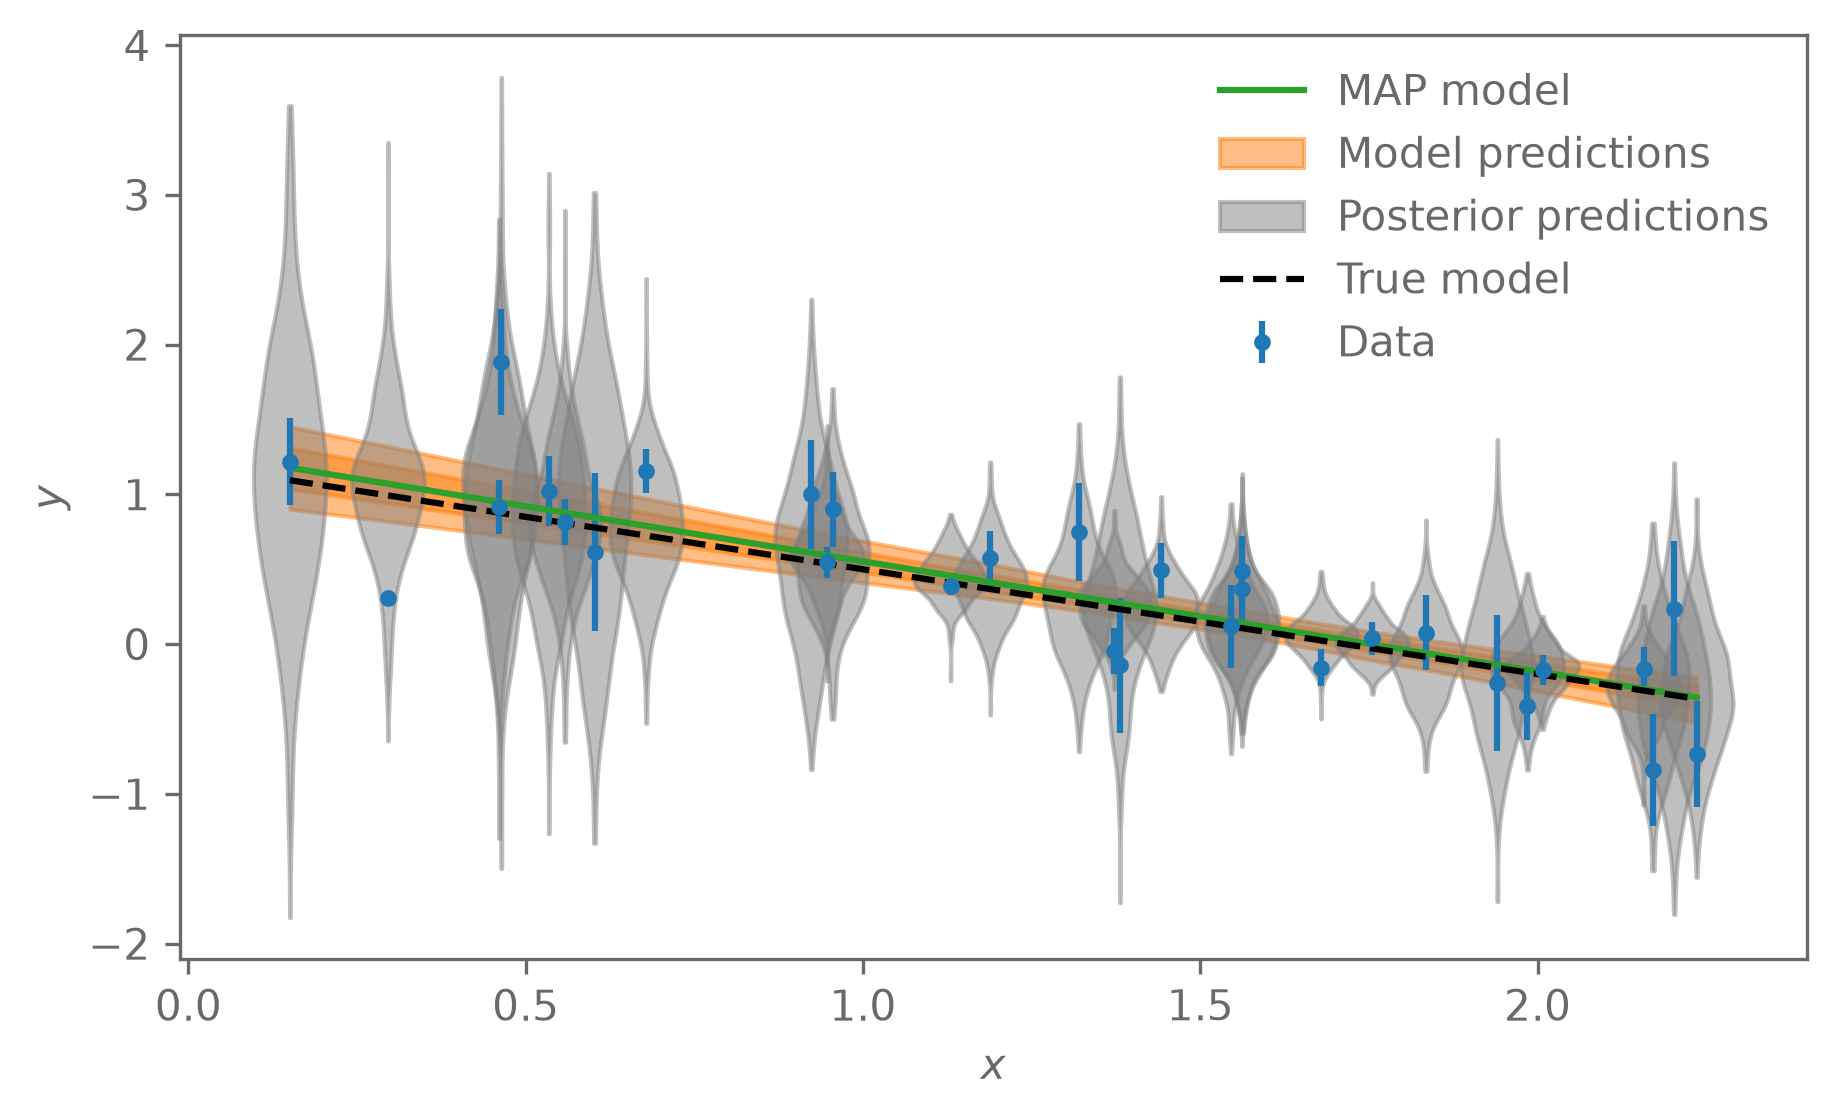

In [77]:
m_true, b_true = -0.7, 1.2
f_true = 0.51
f_true = 0.51
output_true = analyse_data(
    data=dict(x=x, y=y, y_err=yerr),
    log_posterior_fn=log_posterior_true,
    model_fn=lambda theta, x: model(theta[:2], x),
    predict_fn=predict_true,
    param_names=["m", "b", "f"],
    theta_true=[m_true, b_true, f_true],
)

# Ex2

Start with getting data & plotting it

In [80]:
time, distance, distance_alt, sigma_d=np.loadtxt(f"../my_exercise_solutions/data/jovian_moons/Europa.dat",unpack=True)

Text(0, 0.5, 'Distance[km] x $10^{-6}$')

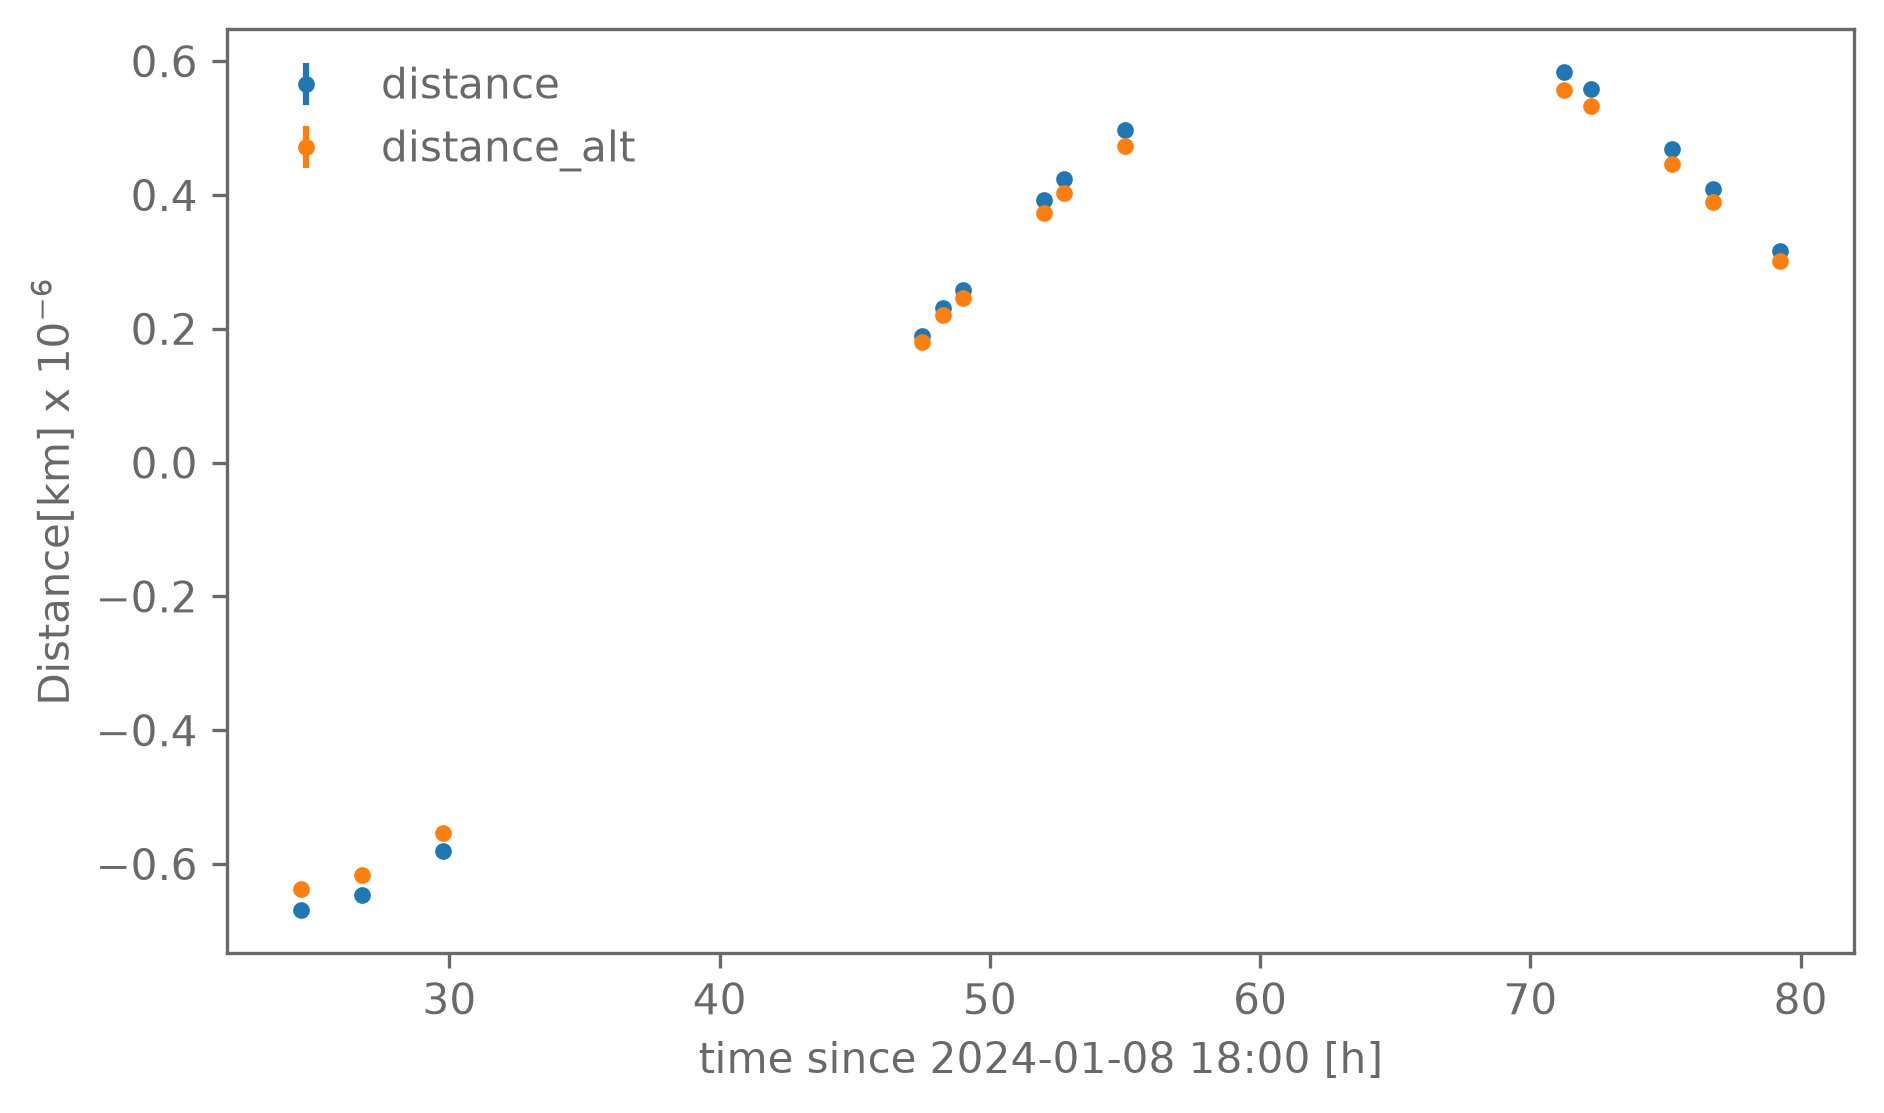

In [84]:
plt.errorbar(time, distance,yerr=sigma_d, fmt=".", label="distance")
plt.errorbar(time, distance_alt,yerr=sigma_d, fmt=".", label="distance_alt")
plt.legend()
plt.xlabel("time since 2024-01-08 18:00 [h]")
plt.ylabel("Distance[km] x $10^{-6}$")

## Step1: build model

In [134]:
def model_d(theta, t):
    d, T, phi= theta
    return d*np.sin(t*2*np.pi/T + phi)

def predict_moon_data(theta, t, sigma_d):
    mu=model_d(theta,t)
    return np.random.normal(loc=mu, scale=sigma_d)

def moon_log_likelihood(d,theta,t,sigma_d):
    mu=model_d(theta,t)

    return (
-0.5 * np.sum((d-mu)**2 /sigma_d**2)
-0.5 * np.sum(np.log(2*np.pi*sigma_d**2))

    )

low_a, high_a=0.0, 3.0
low_T,high_T=10,100
low_phi,high_phi=0, 2*np.pi

def moon_log_priors(theta):
    semimajor,period,phase=theta
    if (semimajor < low_a or high_a < semimajor
        or period < low_T or high_T < period
        or phase < low_phi or high_phi < phase):
        return -np.inf
    return 0
def sample_moon_priors(n):
    a=np.random.uniform(low=low_a, high=high_a, size=n)
    T=np.random.uniform(low=low_T,high=high_T, size=n)
    phi=np.random.uniform(low=low_phi, high=high_phi,size=n)
    return np.stack((a,T,phi)).T

    



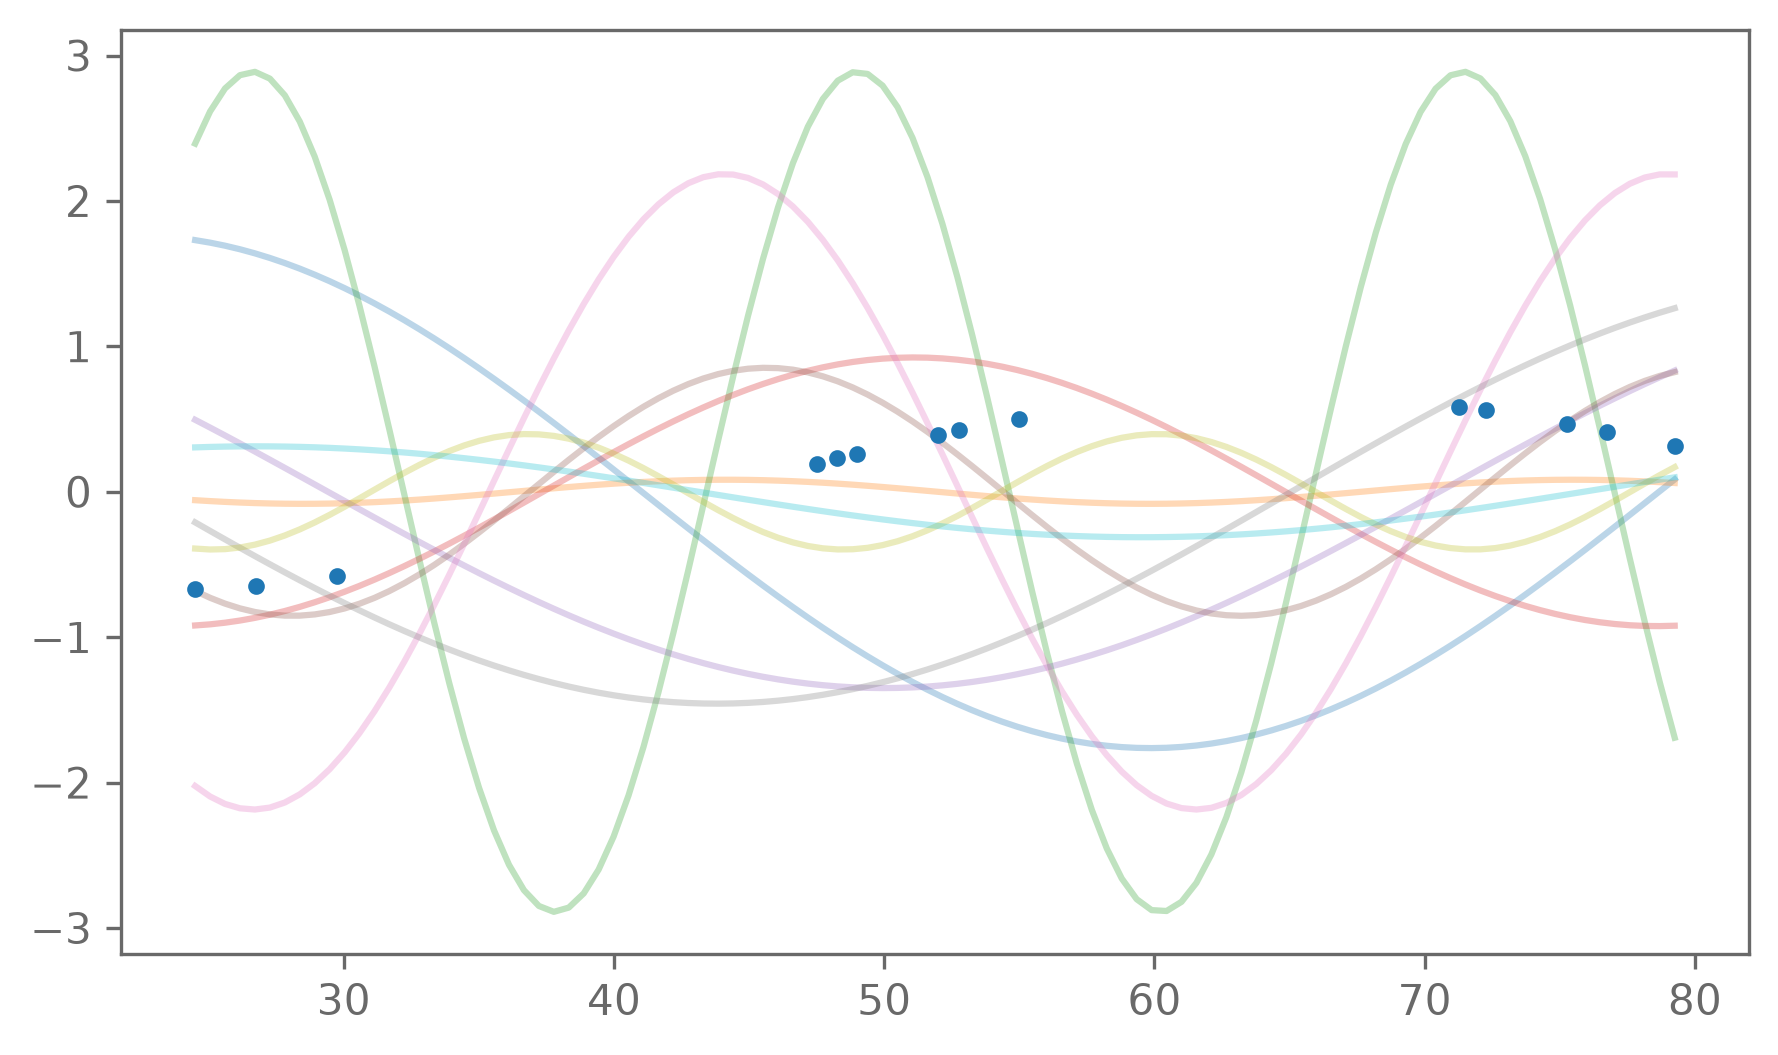

In [135]:
new_time=np.linspace(time[0],time[-1],100)
res=[model_d(params,new_time) for params in sample_moon_priors(10)]
fig,ax=plt.subplots(1,1)

for y in res:
    ax.plot(new_time,y,alpha=0.3)
ax.plot(time,distance, ".", label="observations")

In [156]:
def moon_log_posterior(theta,d,t,sigma_d):
    return moon_log_likelihood(d,theta,t,sigma_d) + moon_log_priors(theta)

moon_MAP=scipy.optimize.minimize(
    fun= lambda theta: -moon_log_posterior(theta=theta,d=distance,t=time,sigma_d=sigma_d),
    x0=[1,50,1], method="Nelder-Mead"
)
print(f"Optimisation successful: {moon_MAP.success}")

Optimisation successful: True


In [157]:
a_MAP,T_MAP,phi_MAP = moon_MAP.x
print("MAP results")
print(f"{a_MAP=:.3f}, {T_MAP=:.3f}, {phi_MAP=:.3f}")

MAP results
a_MAP=0.671, T_MAP=83.620, phi_MAP=3.001


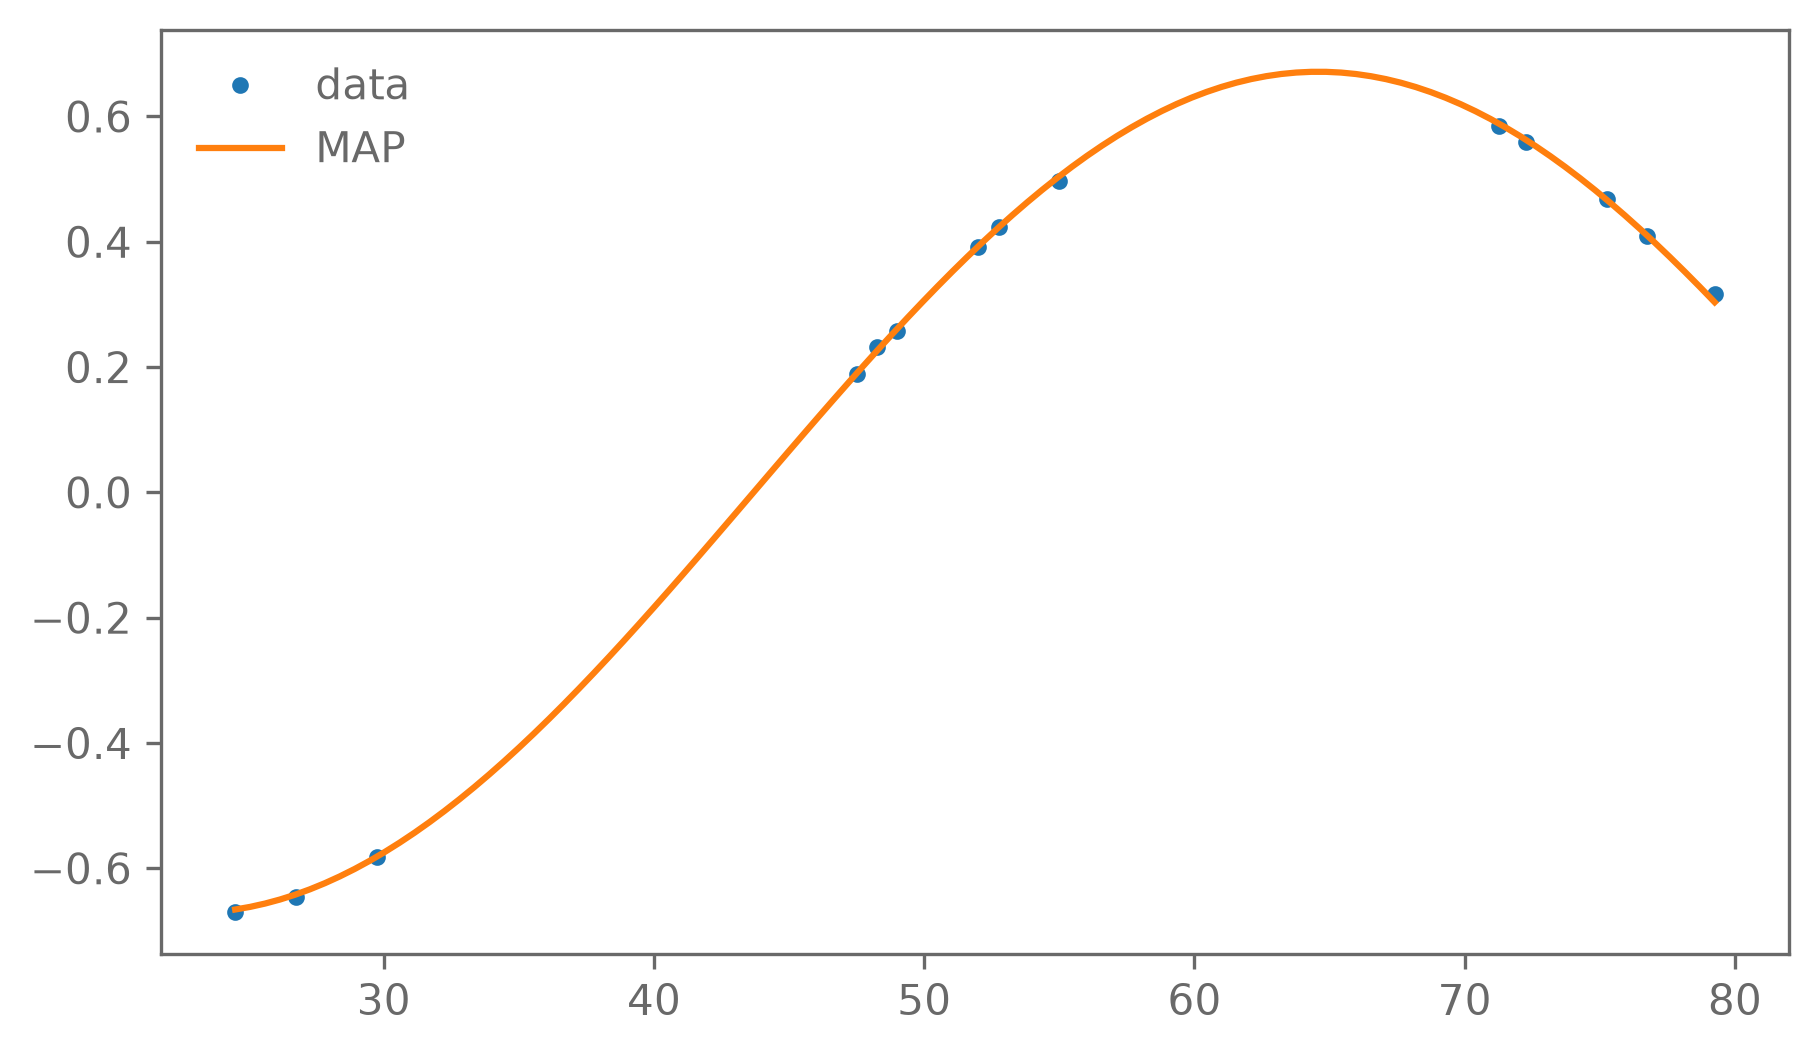

In [158]:
plt.plot(time, distance, ".", label="data")
plt.plot(new_time,model_d([a_MAP,T_MAP,phi_MAP], new_time), label="MAP")
plt.legend()

In [140]:
?scipy.optimize.minimize

Signature:
scipy.optimize.minimize(
    fun,
    x0,
    args=(),
    method=None,
    jac=None,
    hess=None,
    hessp=None,
    bounds=None,
    constraints=(),
    tol=None,
    callback=None,
    options=None,
)
Docstring:
Minimization of scalar function of one or more variables.

Parameters
----------
fun : callable
    The objective function to be minimized::

        fun(x, *args) -> float

    where ``x`` is a 1-D array with shape (n,) and ``args``
    is a tuple of the fixed parameters needed to completely
    specify the function.

    Suppose the callable has signature ``f0(x, *my_args, **my_kwargs)``, where
    ``my_args`` and ``my_kwargs`` are required positional and keyword arguments.
    Rather than passing ``f0`` as the callable, wrap it to accept
    only ``x``; e.g., pass ``fun=lambda x: f0(x, *my_args, **my_kwargs)`` as the
    callable, where ``my_args`` (tuple) and ``my_kwargs`` (dict) have been
    gathered before invoking this function.
x0 : ndarray, shape (n,)

In [118]:
sample_moon_priors(1)

array([[ 0.82253232, 29.98681299,  1.80897125]])